In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# ============================================================
# Cell 1:
# Setup for graphs for the new pipeline: Hebrew BERT + Sen2Pro-style
#
# The original cell included a merge step for data before/after a crash.
# The new pipeline does not need this type of recovery:
# Each iteration is saved as a separate file:
#   res_report_<iteration>_bert_sen2pro.csv
#
# This cell:
# 1. Scans the new results directory.
# 2. Loads all BERT/Sen2Pro res_report files.
# 3. Builds one table:
#       Names, 1, 2, 3, ..., N
#    where each column is the anomaly_score of one iteration.
# 4. Computes a paired-t matrix across the iterations.
# 5. Runs K-Medoids on the paired-t matrix.
#
# The following cells produce the same plots as the old notebook.
# ============================================================

from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except ImportError:
    display = print


# ============================================================
# Basic settings
# ============================================================

# Results directory for the new pipeline
RESULTS_DIR = Path("/content/drive/MyDrive/deep_imposters_final_project/hebrew_bert_sen2pro_results/")

# Model tag as it appears in the new file names:
# res_report_<iteration>_bert_sen2pro.csv
MODEL_TAG = "bert_sen2pro"

# To limit the iteration range, set numeric values.
# If left as None, the code loads all existing iterations in the directory.
FIRST_ITERATION = None
LAST_ITERATION = None

# Iteration from which to start the evolution plot.
# For example, if there are 90 iterations, start checking from 10 through 90.
START_EVOLUTION_ITERATION = 10

# Fixed randomness for reproducible results
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


# ============================================================
# General plotting settings
# ============================================================

SHOW_NAMES_ON_GRAPHS = True

MATRIX_FIGSIZE = (30, 28)
EVOLUTION_FIGSIZE = (24, 36)

AXIS_LABEL_FONT_SIZE = 4
EVOLUTION_AXIS_LABEL_FONT_SIZE = 5


# ============================================================
# General helper functions
# ============================================================

def chapter_to_book(chapter_name: str) -> str:
    """
    Receives a chapter name such as:
    Bamidbar_CH7

    and returns:
    Bamidbar
    """
    return str(chapter_name).split("_CH")[0]


def extract_iteration_from_res_report_path(file_path: Path, model_tag: str = MODEL_TAG):
    """
    Extracts the iteration number from a file name such as:
    res_report_9_bert_sen2pro.csv
    """
    pattern = rf"^res_report_(\d+)_{re.escape(model_tag)}\.csv$"
    match = re.match(pattern, file_path.name)

    if not match:
        return None

    return int(match.group(1))


def find_res_report_files(results_dir: Path, model_tag: str = MODEL_TAG):
    """
    Finds all res_report files from the new pipeline in the results directory.

    Returns a list of tuples:
        (iteration_number, file_path)
    sorted by iteration number.
    """
    if not results_dir.exists():
        raise FileNotFoundError(f"The results directory does not exist:\n{results_dir}")

    candidates = list(results_dir.glob(f"res_report_*_{model_tag}.csv"))

    iteration_files = []

    for file_path in candidates:
        iteration = extract_iteration_from_res_report_path(file_path, model_tag=model_tag)
        if iteration is not None:
            iteration_files.append((iteration, file_path))

    iteration_files = sorted(iteration_files, key=lambda item: item[0])

    if FIRST_ITERATION is not None:
        iteration_files = [item for item in iteration_files if item[0] >= FIRST_ITERATION]

    if LAST_ITERATION is not None:
        iteration_files = [item for item in iteration_files if item[0] <= LAST_ITERATION]

    if not iteration_files:
        raise FileNotFoundError(
            "No res_report files for the new pipeline were found in the directory:\n"
            f"{results_dir}\n"
            f"expected pattern: res_report_<iteration>_{model_tag}.csv"
        )

    return iteration_files


def find_anomaly_score_column(df: pd.DataFrame, iteration: int):
    """
    Finds the anomaly_score column in a file for a specific iteration.

    In the new pipeline, the expected name is:
        iteration_<iteration>_anomaly_score

    If the name is slightly different, look for any column containing anomaly_score.
    """
    expected_column = f"iteration_{iteration}_anomaly_score"

    if expected_column in df.columns:
        return expected_column

    candidates = [col for col in df.columns if "anomaly_score" in str(col)]

    if len(candidates) == 1:
        return candidates[0]

    raise ValueError(
        f"Could not identify the anomaly_score column for iteration {iteration}.\n"
        f"Columns in the file: {df.columns.tolist()}"
    )


def check_iteration_sequence(iterations):
    """
    Checks whether the iteration numbers are continuous.
    The new pipeline should not have a crash/cutoff, so a full sequence is preferred.
    """
    iterations = sorted(iterations)
    expected = list(range(iterations[0], iterations[-1] + 1))
    missing = sorted(set(expected) - set(iterations))

    print("\nIteration sequence check:")
    print("First iteration:", iterations[0])
    print("Last iteration:", iterations[-1])
    print("Number of res_report files found:", len(iterations))

    if missing:
        print("Warning: missing iterations:")
        print(missing)
    else:
        print("All iterations are continuous in the detected range.")

    return missing


def build_final_df_from_new_pipeline_reports(results_dir: Path, model_tag: str = MODEL_TAG):
    """
    Loads all new-pipeline res_report files and builds a single table:

        Names, 1, 2, 3, ..., N

    Each numeric column is the anomaly_score of that iteration.

    Note:
    Unlike the old notebook, there is no before/after-crash merge here.
    Each iteration is saved as an independent file, so the code simply scans all files.
    """
    iteration_files = find_res_report_files(results_dir, model_tag=model_tag)
    iterations = [iteration for iteration, _ in iteration_files]

    print("res_report files found:")
    print("Number of files:", len(iteration_files))
    print("First iterations:", iterations[:10])
    print("Last iterations:", iterations[-10:])

    check_iteration_sequence(iterations)

    merged_df = None

    for iteration, file_path in iteration_files:
        df = pd.read_csv(file_path)

        if "Names" not in df.columns:
            raise ValueError(f"The Names column was not found in the file:\n{file_path}")

        score_column = find_anomaly_score_column(df, iteration)

        one_iteration_df = df[["Names", score_column]].copy()
        one_iteration_df["Names"] = one_iteration_df["Names"].astype(str)
        one_iteration_df = one_iteration_df.rename(columns={score_column: str(iteration)})

        if merged_df is None:
            merged_df = one_iteration_df
        else:
            before_count = len(merged_df)
            merged_df = merged_df.merge(one_iteration_df, on="Names", how="inner")
            after_count = len(merged_df)

            if after_count < before_count:
                print(
                    f"Warning: after merging iteration {iteration}, "
                    f"the number of chapters dropped from {before_count} to {after_count}."
                )

    if merged_df is None or merged_df.empty:
        raise ValueError("A valid final_df table was not created.")

    # Sort columns by iteration number
    iteration_columns = [col for col in merged_df.columns if col != "Names"]
    iteration_columns = sorted(iteration_columns, key=lambda col: int(str(col)))

    final_df = merged_df[["Names"] + iteration_columns].copy()

    print("\nFinal table from the new pipeline:")
    print("shape:", final_df.shape)
    print("Number of chapters:", final_df.shape[0])
    print("Number of iterations:", final_df.shape[1] - 1)
    print("First columns:", final_df.columns[:10].tolist())
    print("Last columns:", final_df.columns[-10:].tolist())

    display(final_df.head())

    return final_df


def prepare_scores_from_final_df(final_df: pd.DataFrame):
    """
    Receives final_df and prepares:

    chapter_names - chapter names
    score_columns - iteration columns
    scores_df - numeric score table
    X - NumPy matrix
    """
    if "Names" not in final_df.columns:
        raise ValueError("final_df must contain a Names column.")

    chapter_names = final_df["Names"].astype(str).reset_index(drop=True)

    score_columns = [col for col in final_df.columns if col != "Names"]
    score_columns = sorted(score_columns, key=lambda c: int(str(c)))

    scores_df = final_df[score_columns].apply(pd.to_numeric, errors="coerce")

    missing_values = scores_df.isna().sum().sum()

    print("\nMissing values check:")
    print("Number of missing values:", missing_values)

    if missing_values > 0:
        print("Filling missing values with the column mean.")
        scores_df = scores_df.fillna(scores_df.mean())

    X = scores_df.values

    print("\nScore matrix:")
    print("Number of chapters:", X.shape[0])
    print("Number of iterations:", X.shape[1])

    return chapter_names, score_columns, scores_df, X


# ============================================================
# Distance and K-Medoids calculation functions
# ============================================================

def paired_t_distance_matrix(X):
    """
    Computes a distance matrix between every pair of chapters.

    Each row in X is a chapter.
    Each column in X is an iteration.

    For a pair of chapters i,j:

    diff = X[i] - X[j]

    Then compute the paired t-statistic:

    t = mean(diff) / (std(diff) / sqrt(n))

    Finally, take the absolute value:

    distance = abs(t)

    Meaning:
    If two chapters behave similarly across all iterations,
    the differences between them are smaller and less consistently separated,
    so the distance will be small.

    If they behave consistently differently,
    the distance will be large.
    """

    X = np.asarray(X, dtype=float)
    n_docs, n_features = X.shape

    dist = np.zeros((n_docs, n_docs), dtype=float)

    for i in range(n_docs):
        for j in range(i + 1, n_docs):

            diff = X[i] - X[j]

            mean_diff = np.mean(diff)
            std_diff = np.std(diff, ddof=1)

            if std_diff == 0 or np.isnan(std_diff):
                if abs(mean_diff) < 1e-12:
                    t_value = 0.0
                else:
                    t_value = 1e6
            else:
                t_value = mean_diff / (std_diff / np.sqrt(n_features))

            distance = abs(t_value)

            dist[i, j] = distance
            dist[j, i] = distance

    np.fill_diagonal(dist, 0.0)

    return dist


def simple_kmedoids_precomputed(
    distance_matrix,
    n_clusters=2,
    max_iter=100,
    random_state=42
):
    """
    Simple K-Medoids implementation on a precomputed distance matrix.

    Unlike K-Means, this does not compute averaged points,
    but selects real data points as centers.

    This fits here because a distance matrix already exists,
    and the data is not necessarily ordinary geometric vectors.
    """

    rng = np.random.default_rng(random_state)
    n = distance_matrix.shape[0]

    medoids = rng.choice(n, size=n_clusters, replace=False)

    for _ in range(max_iter):

        distances_to_medoids = distance_matrix[:, medoids]
        labels = np.argmin(distances_to_medoids, axis=1)

        new_medoids = medoids.copy()

        for cluster_id in range(n_clusters):

            members = np.where(labels == cluster_id)[0]

            if len(members) == 0:
                new_medoids[cluster_id] = rng.integers(0, n)
                continue

            intra_distances = distance_matrix[np.ix_(members, members)]
            total_distances = intra_distances.sum(axis=1)

            best_member = members[np.argmin(total_distances)]
            new_medoids[cluster_id] = best_member

        if np.array_equal(medoids, new_medoids):
            break

        medoids = new_medoids

    final_distances = distance_matrix[:, medoids]
    labels = np.argmin(final_distances, axis=1)

    return labels, medoids


def align_labels_small_cluster_is_1(labels):
    """
    Aligns the cluster labels.

    Because K-Medoids can assign cluster IDs 0/1 arbitrarily,
    a fixed rule is used:

    The smaller cluster receives label 1.
    The larger cluster receives label 2.

    According to the analysis logic:
    1 = suspicious / smaller cluster
    2 = core / larger cluster
    """

    labels = np.asarray(labels)

    unique, counts = np.unique(labels, return_counts=True)

    if len(unique) != 2:
        raise ValueError("Exactly two clusters are required.")

    small_cluster = unique[np.argmin(counts)]
    large_cluster = unique[np.argmax(counts)]

    aligned = np.where(labels == small_cluster, 1, 2)

    return aligned


def cluster_score_vectors(X, random_state=42):
    """
    Receives score matrix X:

    Rows = chapters
    Columns = iterations

    and returns:

    aligned_labels:
        1 = suspicious / smaller cluster
        2 = core / larger cluster

    distance_matrix:
        paired-t distance matrix

    medoids:
        the indices of the medoids
    """

    distance_matrix = paired_t_distance_matrix(X)

    raw_labels, medoids = simple_kmedoids_precomputed(
        distance_matrix,
        n_clusters=2,
        random_state=random_state
    )

    aligned_labels = align_labels_small_cluster_is_1(raw_labels)

    return aligned_labels, distance_matrix, medoids


def set_all_chapter_ticks(chapter_labels, x_axis=True, y_axis=True, font_size=4):
    """
    Adds chapter names to the heatmap axes.
    This can be crowded, but helps identify where each chapter appears.
    """

    positions = np.arange(len(chapter_labels))

    if x_axis:
        plt.xticks(
            positions,
            chapter_labels,
            rotation=90,
            fontsize=font_size
        )

    if y_axis:
        plt.yticks(
            positions,
            chapter_labels,
            fontsize=font_size
        )


# ============================================================
# Run the actual preparation step
# ============================================================

final_df = build_final_df_from_new_pipeline_reports(
    results_dir=RESULTS_DIR,
    model_tag=MODEL_TAG
)

chapter_names, score_columns, scores_df, X = prepare_scores_from_final_df(final_df)

n_documents, n_iterations = X.shape

straight_labels, full_distance_matrix, full_medoids = cluster_score_vectors(
    X,
    random_state=RANDOM_STATE
)

straight_is_suspicious = (straight_labels == 1).astype(int)

analysis_df = pd.DataFrame({
    "chapter": chapter_names,
    "book": chapter_names.apply(chapter_to_book),
    "mean_anomaly_score": scores_df.mean(axis=1),
    "median_anomaly_score": scores_df.median(axis=1),
    "min_anomaly_score": scores_df.min(axis=1),
    "negative_count": (scores_df < 0).sum(axis=1),
    "negative_ratio": (scores_df < 0).mean(axis=1),
    "straight_label": straight_labels,
    "straight_suspicious": straight_is_suspicious,
})

print("\nK-Medoids summary using all iterations from the new pipeline:")
print("Number of suspicious / smaller cluster chapters:", int(straight_is_suspicious.sum()))
print("Number of core / larger cluster chapters:", int(len(straight_is_suspicious) - straight_is_suspicious.sum()))

print("\nChapters in the smaller cluster according to K-Medoids:")
display(
    analysis_df[analysis_df["straight_label"] == 1]
    .sort_values(["negative_count", "mean_anomaly_score"], ascending=[False, True])
)


res_report files found:
Number of files: 90
First iterations: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Last iterations: [81, 82, 83, 84, 85, 86, 87, 88, 89, 90]

Iteration sequence check:
First iteration: 1
Last iteration: 90
Number of res_report files found: 90
All iterations are continuous in the detected range.

Final table from the new pipeline:
shape: (183, 91)
Number of chapters: 183
Number of iterations: 90
First columns: ['Names', '1', '2', '3', '4', '5', '6', '7', '8', '9']
Last columns: ['81', '82', '83', '84', '85', '86', '87', '88', '89', '90']


,Names,1,2,3,4,5,6,7,8,9,...,81,82,83,84,85,86,87,88,89,90
0,Bamidbar_CH1,-0.306043,0.022632,-0.247096,0.112364,0.035255,-0.243378,0.015228,-0.008567,-0.007740,...,0.072703,-0.014078,0.135486,0.108441,0.136153,0.090192,-0.063944,0.098957,0.022445,0.034211
1,Bamidbar_CH10,0.024546,0.147928,0.048060,0.124914,0.074899,0.044425,0.091591,0.081380,0.121056,...,0.093069,0.075376,0.138140,0.066258,0.134844,0.066865,0.072597,0.107790,0.060166,0.038038
2,Bamidbar_CH11,0.130990,0.083765,0.113337,0.106643,0.062203,0.079266,0.046909,0.144883,0.147158,...,0.064396,0.053963,0.120321,0.108403,0.047822,0.070751,0.059265,0.098581,0.099142,0.107082
3,Bamidbar_CH13,-0.038855,-0.022557,0.058895,0.147966,0.065237,-0.031338,0.099263,-0.076199,-0.085658,...,0.072109,0.078423,0.128858,0.067316,0.024193,0.102495,0.086434,0.005930,0.091816,0.080052
4,Bamidbar_CH14,0.073277,0.106893,-0.022300,0.112328,0.016871,0.070952,0.043214,0.022227,0.111733,...,-0.057263,0.017108,0.050870,0.096629,0.089991,0.044580,0.006328,0.027846,0.077501,0.063962



Missing values check:
Number of missing values: 0

Score matrix:
Number of chapters: 183
Number of iterations: 90

K-Medoids summary using all iterations from the new pipeline:
Number of suspicious / smaller cluster chapters: 74
Number of core / larger cluster chapters: 109

Chapters in the smaller cluster according to K-Medoids:


,chapter,book,mean_anomaly_score,median_anomaly_score,min_anomaly_score,negative_count,negative_ratio,straight_label,straight_suspicious
32,Bamidbar_CH7,Bamidbar,-0.156686,-0.154883,-0.396630,79,0.877778,1,1
51,Beereshit_CH24,Beereshit,-0.084601,-0.076667,-0.336242,75,0.833333,1,1
160,Vaikra_CH13,Vaikra,-0.059129,-0.047147,-0.316420,67,0.744444,1,1
105,Dvarim_CH28,Dvarim,-0.057447,-0.048992,-0.287337,65,0.722222,1,1
161,Vaikra_CH14,Vaikra,-0.053788,-0.041440,-0.285464,61,0.677778,1,1
...,...,...,...,...,...,...,...,...,...
52,Beereshit_CH25,Beereshit,0.074689,0.079613,-0.068941,6,0.066667,1,1
102,Dvarim_CH25,Dvarim,0.080010,0.083949,-0.065931,6,0.066667,1,1
8,Bamidbar_CH18,Bamidbar,0.071700,0.077702,-0.232972,5,0.055556,1,1
68,Beereshit_CH4,Beereshit,0.075201,0.074776,-0.086830,5,0.055556,1,1


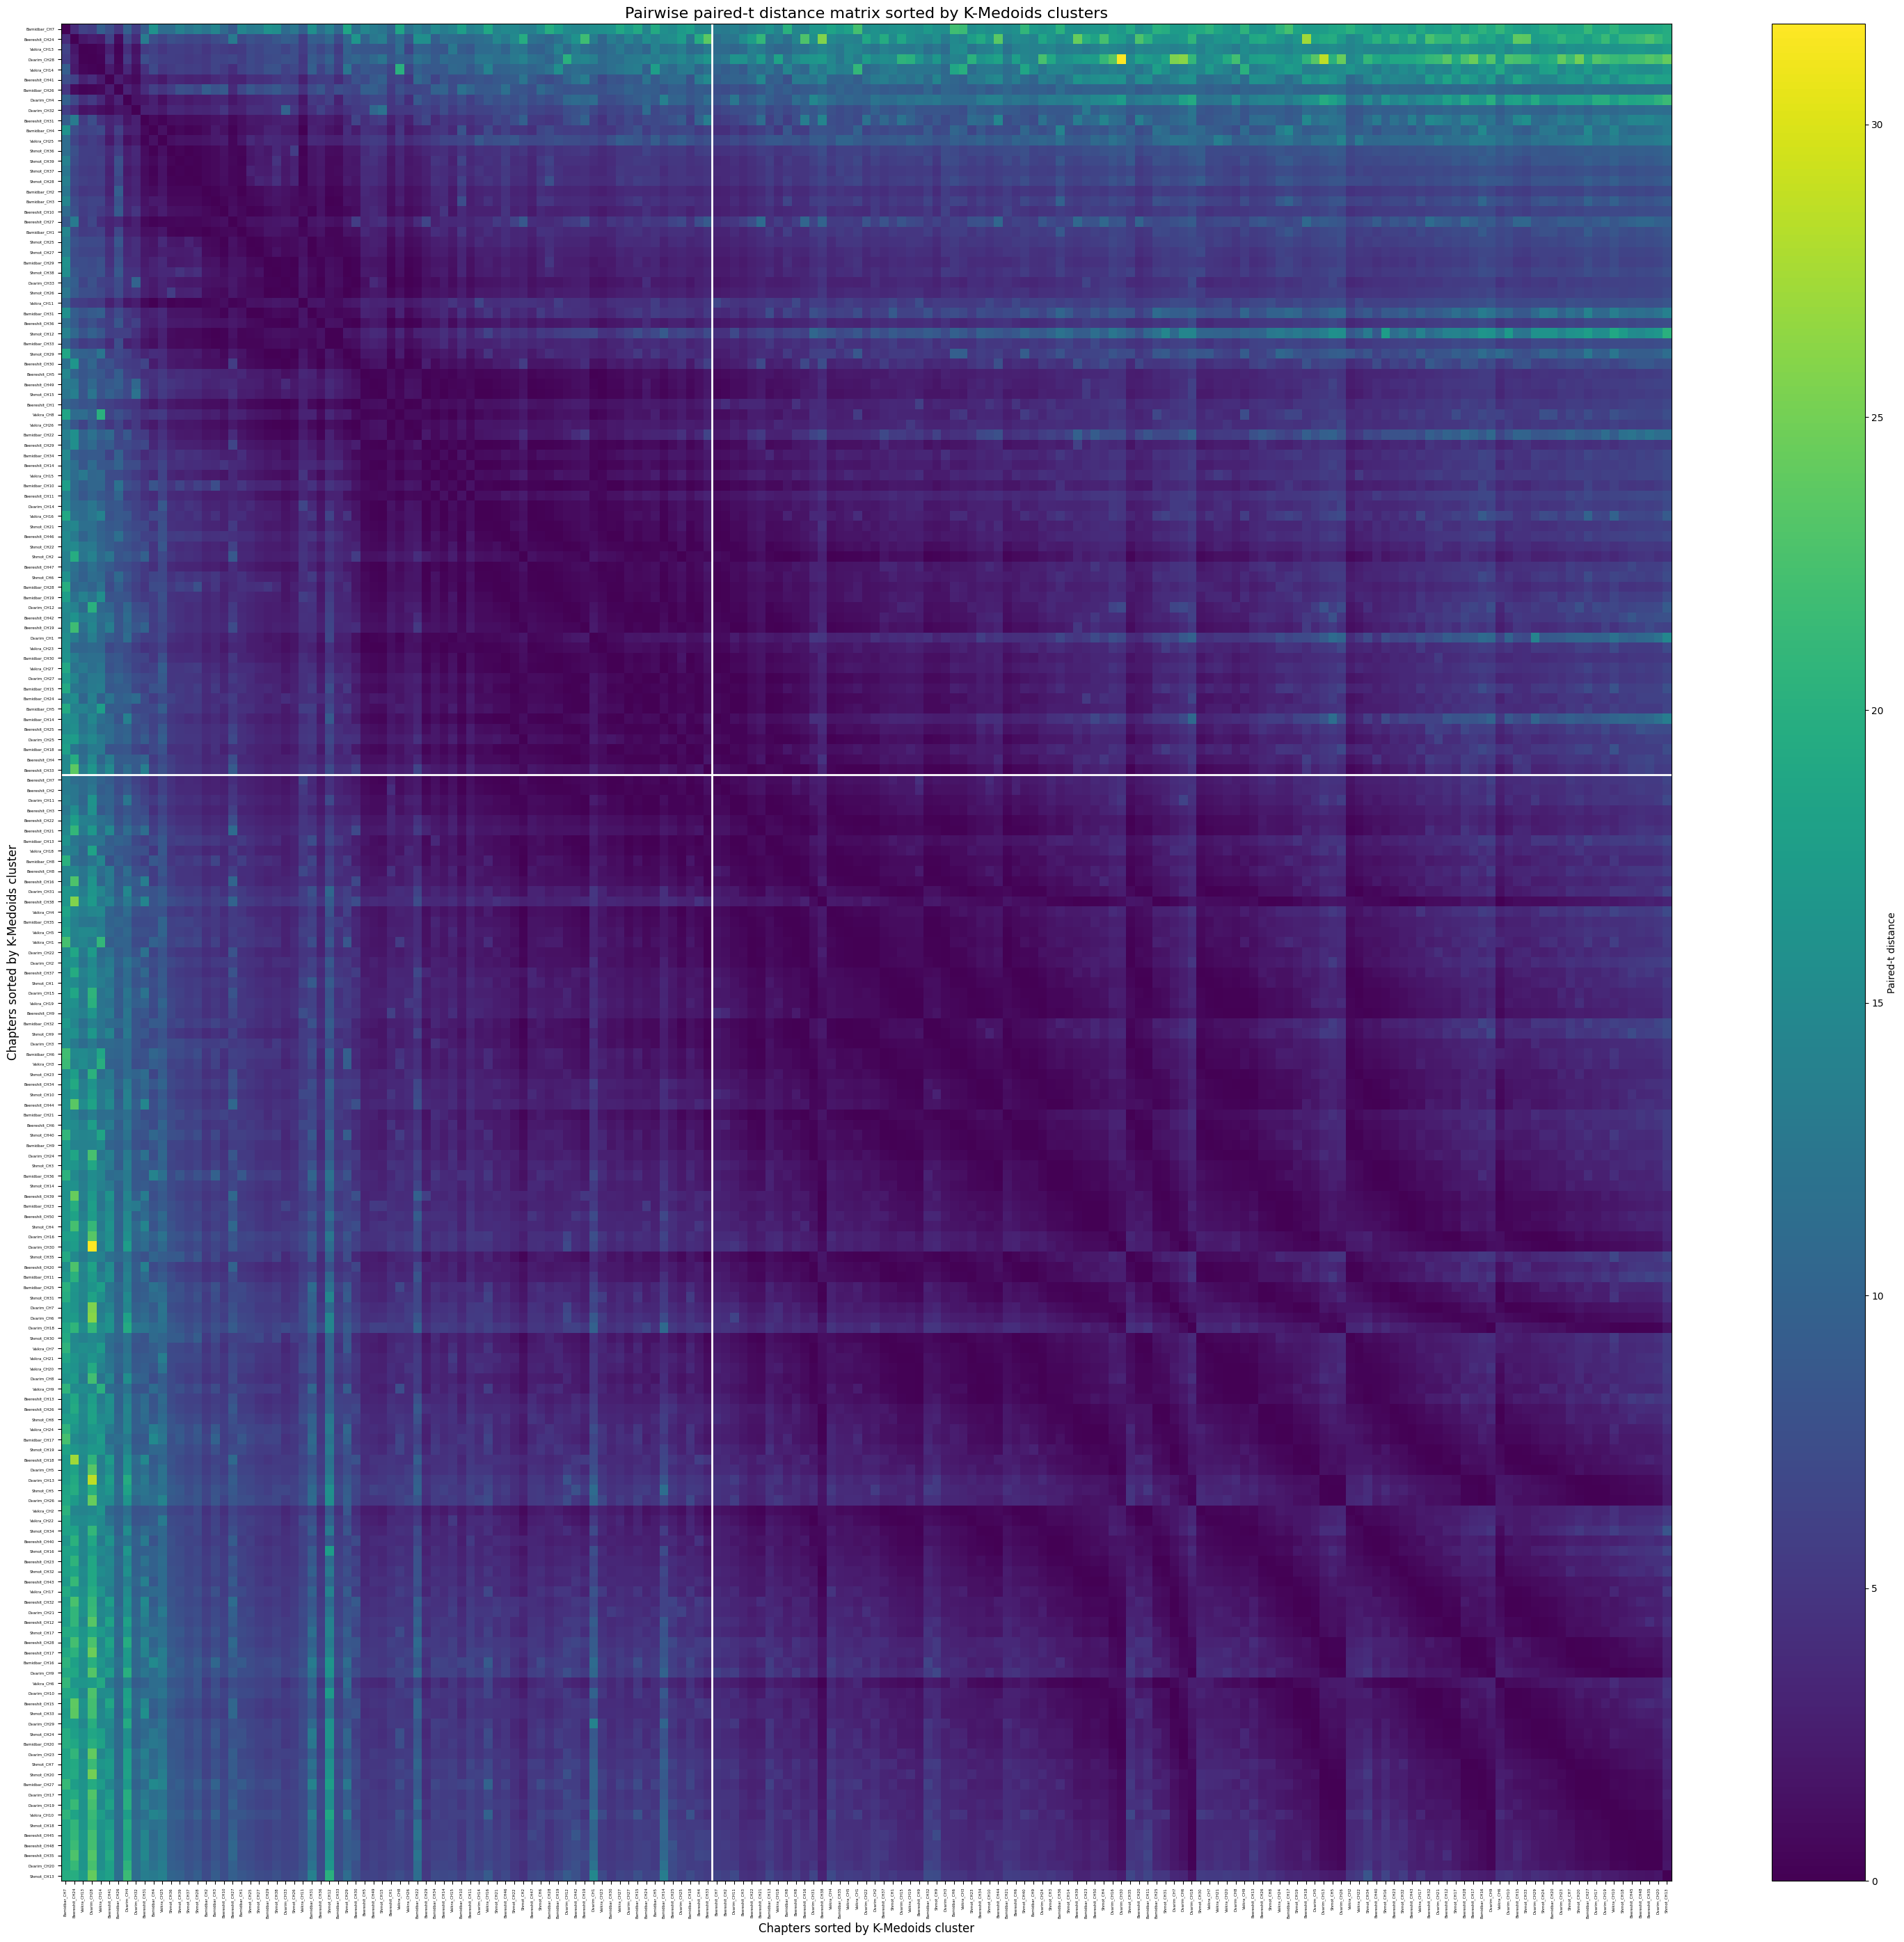

Brief interpretation:
The first block in the matrix is the smaller cluster: label 1 = suspicious.
The second block in the matrix is the larger cluster: label 2 = core.
A stronger color means a larger distance between two chapters according to the paired-t distance.

Suspicious cluster size: 74
Core cluster size: 109


,chapter,book,straight_label,negative_count,negative_ratio,mean_anomaly_score
0,Bamidbar_CH7,Bamidbar,1,79,0.877778,-0.156686
1,Beereshit_CH24,Beereshit,1,75,0.833333,-0.084601
2,Vaikra_CH13,Vaikra,1,67,0.744444,-0.059129
3,Dvarim_CH28,Dvarim,1,65,0.722222,-0.057447
4,Vaikra_CH14,Vaikra,1,61,0.677778,-0.053788
...,...,...,...,...,...,...
178,Beereshit_CH45,Beereshit,2,0,0.000000,0.112011
179,Beereshit_CH48,Beereshit,2,0,0.000000,0.112516
180,Beereshit_CH35,Beereshit,2,0,0.000000,0.112577
181,Dvarim_CH20,Dvarim,2,0,0.000000,0.112816


In [4]:
# ============================================================
# Cell 2:
# Plot 1
# Pairwise paired-t distance matrix sorted by K-Medoids clusters
# ============================================================

if "analysis_df" not in globals():
    raise RuntimeError("analysis_df was not found. Run Cell 1 first.")

if "full_distance_matrix" not in globals():
    raise RuntimeError("full_distance_matrix was not found. Run Cell 1 first.")

if "straight_labels" not in globals():
    raise RuntimeError("straight_labels were not found. Run Cell 1 first.")


# ------------------------------------------------------------
# Sort chapters by their assigned cluster
#
# First suspicious / smaller cluster = label 1
# Then core / larger cluster = label 2
#
# Within each cluster:
# Chapters that were anomalous more often appear earlier.
# ------------------------------------------------------------

sorted_indices = (
    analysis_df
    .sort_values(
        ["straight_label", "negative_count", "mean_anomaly_score"],
        ascending=[True, False, True]
    )
    .index
    .to_numpy()
)

sorted_distance_matrix = full_distance_matrix[np.ix_(sorted_indices, sorted_indices)]
sorted_chapter_names = analysis_df.loc[sorted_indices, "chapter"].to_numpy()


# ------------------------------------------------------------
# Draw the distance matrix
# ------------------------------------------------------------

plt.figure(figsize=MATRIX_FIGSIZE)

plt.imshow(
    sorted_distance_matrix,
    aspect="auto"
)

plt.title(
    "Pairwise paired-t distance matrix sorted by K-Medoids clusters",
    fontsize=16
)

plt.xlabel("Chapters sorted by K-Medoids cluster", fontsize=12)
plt.ylabel("Chapters sorted by K-Medoids cluster", fontsize=12)

plt.colorbar(label="Paired-t distance")


# ------------------------------------------------------------
# Separator line between clusters
# ------------------------------------------------------------

cluster_1_size = int((straight_labels == 1).sum())

plt.axhline(
    cluster_1_size - 0.5,
    color="white",
    linewidth=2
)

plt.axvline(
    cluster_1_size - 0.5,
    color="white",
    linewidth=2
)


# ------------------------------------------------------------
# Display chapter names on the axes
# ------------------------------------------------------------

if SHOW_NAMES_ON_GRAPHS:
    set_all_chapter_ticks(
        chapter_labels=sorted_chapter_names,
        x_axis=True,
        y_axis=True,
        font_size=AXIS_LABEL_FONT_SIZE
    )

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Small helper table for understanding the plot
# ------------------------------------------------------------

print("Brief interpretation:")
print("The first block in the matrix is the smaller cluster: label 1 = suspicious.")
print("The second block in the matrix is the larger cluster: label 2 = core.")
print("A stronger color means a larger distance between two chapters according to the paired-t distance.")

print("\nSuspicious cluster size:", cluster_1_size)
print("Core cluster size:", len(straight_labels) - cluster_1_size)

display(
    analysis_df
    .sort_values(
        ["straight_label", "negative_count", "mean_anomaly_score"],
        ascending=[True, False, True]
    )
    [["chapter", "book", "straight_label", "negative_count", "negative_ratio", "mean_anomaly_score"]]
    .reset_index(drop=True)
)


Evolution of cluster assignments summary:
Number of suspicious chapters according to evolution: 41
Number of core chapters according to evolution: 142

Suspicious chapters according to evolution:


,chapter,book,average_evolution_label,negative_count,negative_ratio,mean_anomaly_score
32,Bamidbar_CH7,Bamidbar,1.283951,79,0.877778,-0.156686
161,Vaikra_CH14,Vaikra,1.283951,61,0.677778,-0.053788
51,Beereshit_CH24,Beereshit,1.296296,75,0.833333,-0.084601
54,Beereshit_CH27,Beereshit,1.296296,28,0.311111,0.012312
105,Dvarim_CH28,Dvarim,1.296296,65,0.722222,-0.057447
23,Bamidbar_CH31,Bamidbar,1.308642,22,0.244444,0.037304
17,Bamidbar_CH26,Bamidbar,1.308642,50,0.555556,-0.065731
10,Bamidbar_CH2,Bamidbar,1.308642,31,0.344444,0.027226
36,Beereshit_CH10,Beereshit,1.308642,30,0.333333,0.034244
25,Bamidbar_CH33,Bamidbar,1.308642,21,0.233333,0.031470


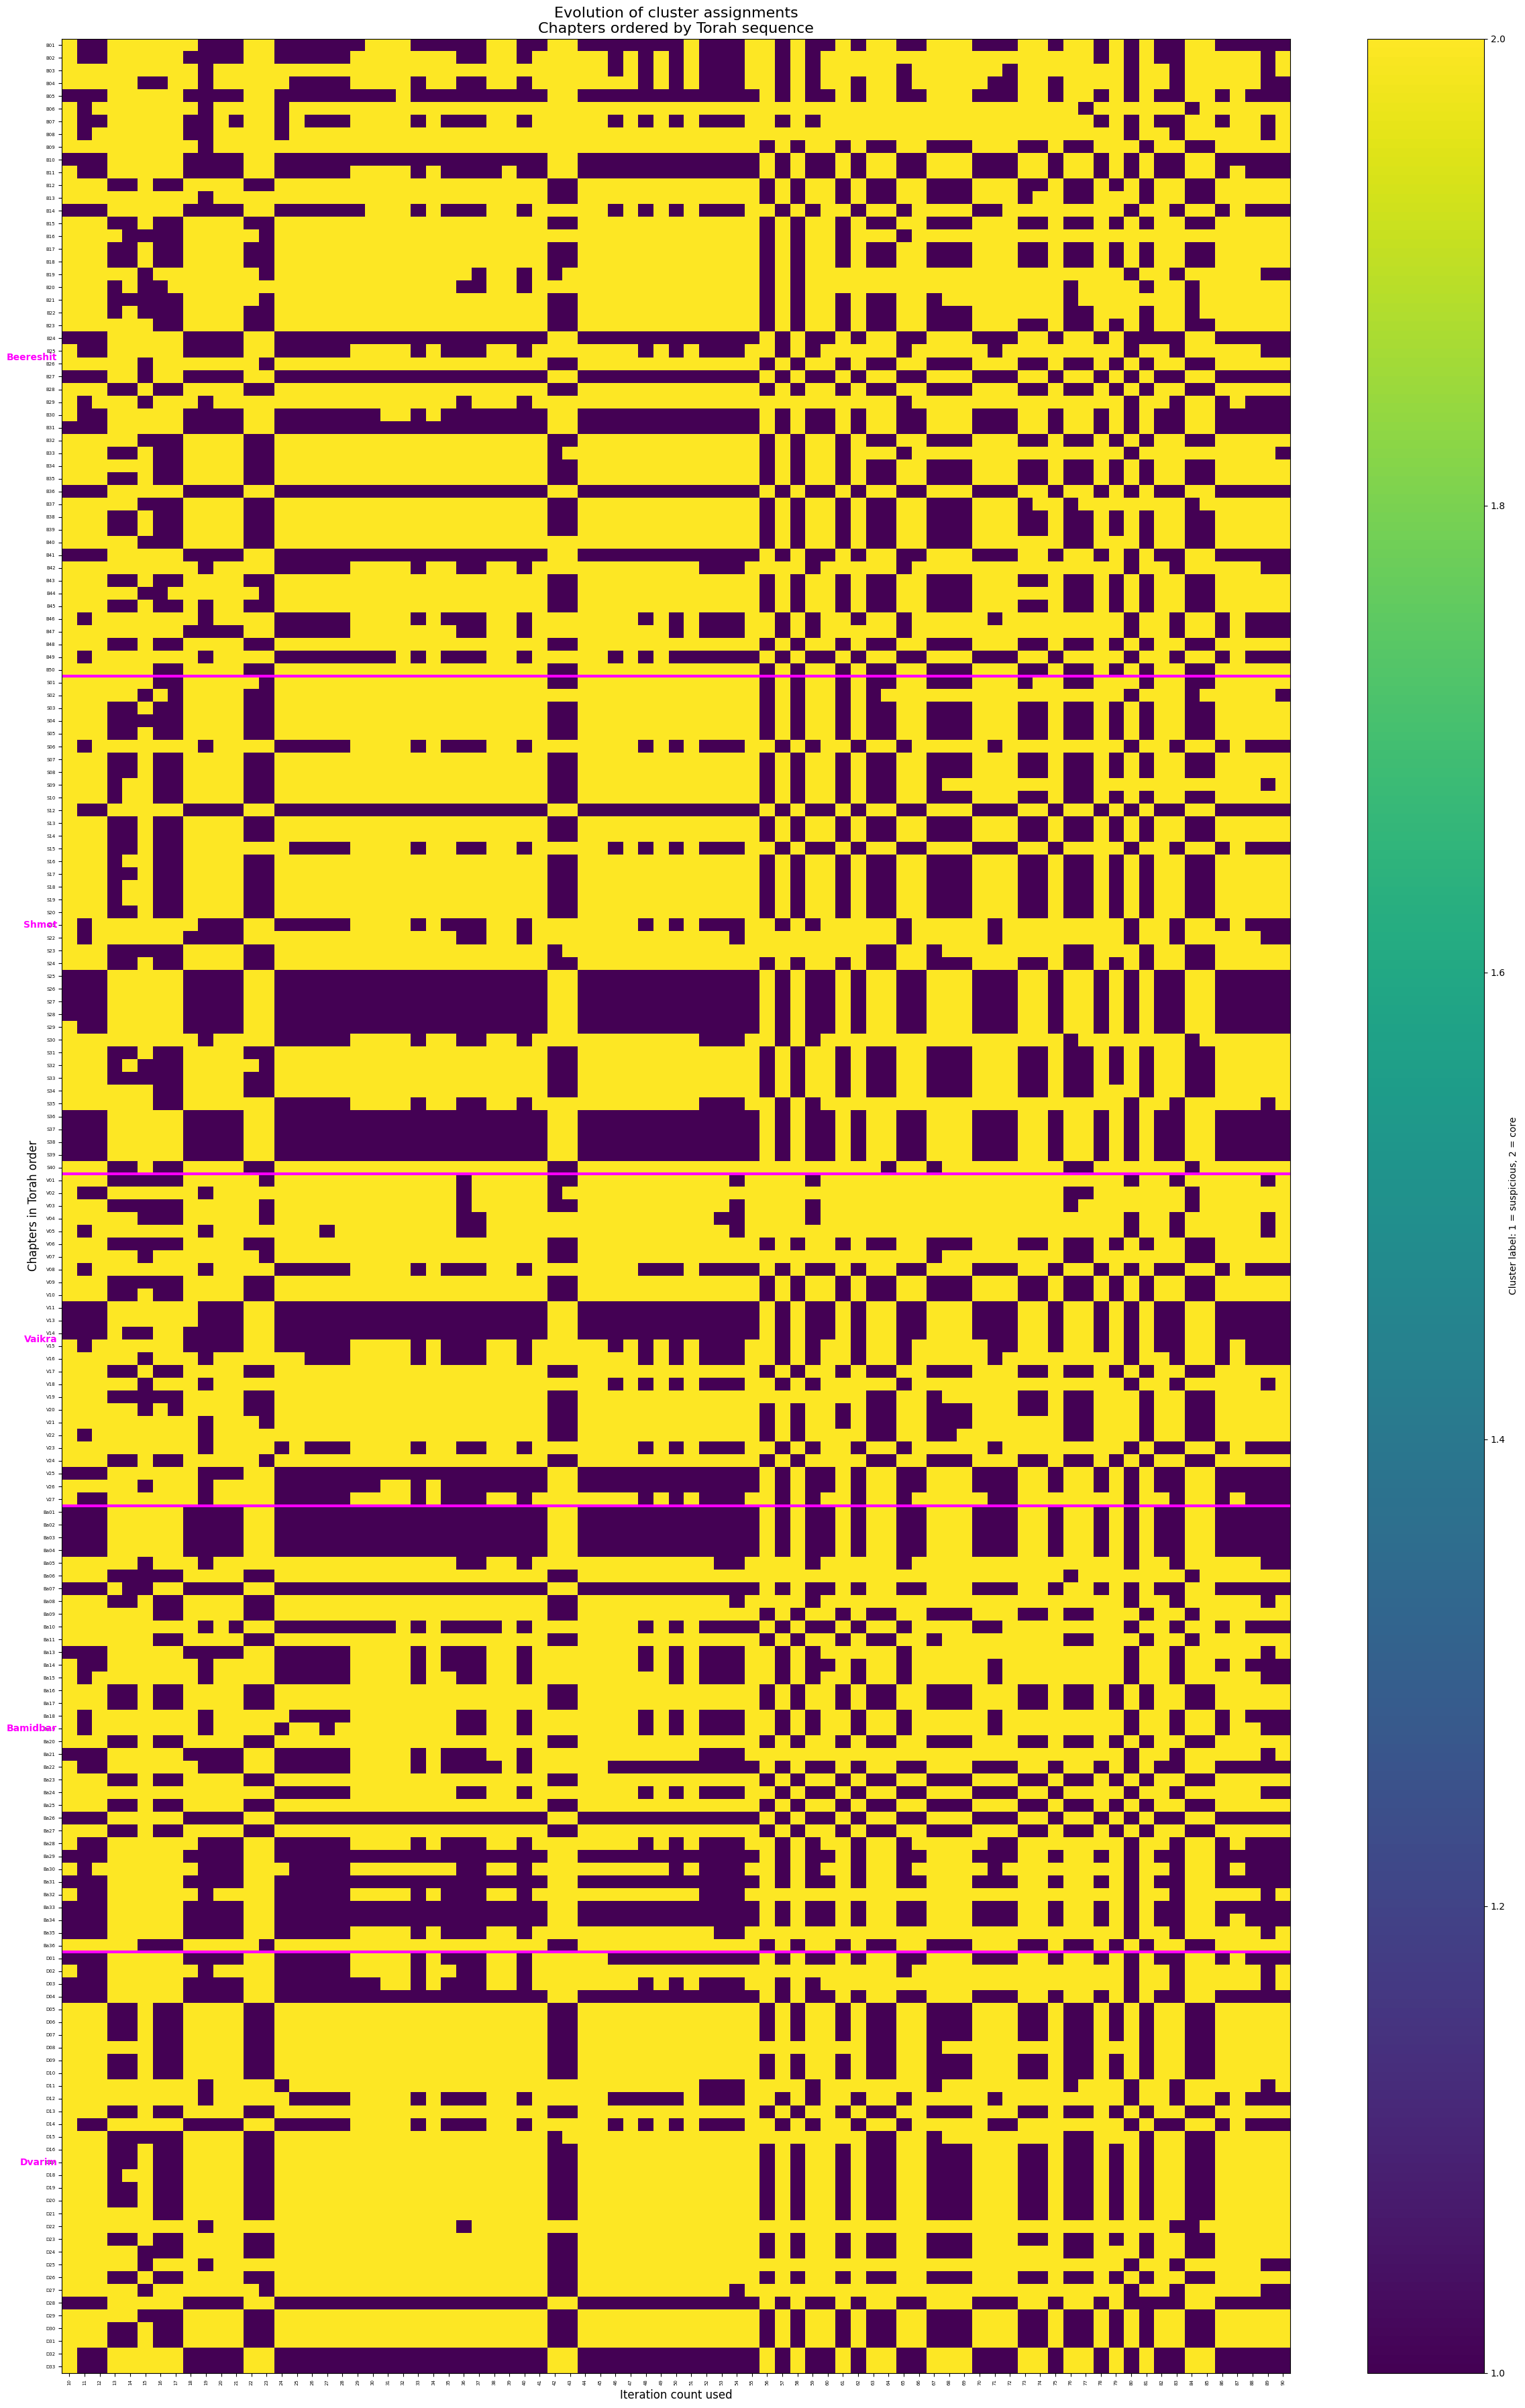

Evolution table in Torah order:


,chapter,book,chapter_number,average_evolution_label,evolution_suspicious,negative_count,negative_ratio,mean_anomaly_score
0,Beereshit_CH1,Beereshit,1,1.419753,1,17,0.188889,0.048260
1,Beereshit_CH2,Beereshit,2,1.666667,0,11,0.122222,0.071884
2,Beereshit_CH3,Beereshit,3,1.827160,0,10,0.111111,0.077517
3,Beereshit_CH4,Beereshit,4,1.666667,0,5,0.055556,0.075201
4,Beereshit_CH5,Beereshit,5,1.333333,1,18,0.200000,0.062005
...,...,...,...,...,...,...,...,...
178,Dvarim_CH29,Dvarim,29,1.716049,0,0,0.000000,0.104469
179,Dvarim_CH30,Dvarim,30,1.703704,0,4,0.044444,0.106085
180,Dvarim_CH31,Dvarim,31,1.703704,0,7,0.077778,0.090180
181,Dvarim_CH32,Dvarim,32,1.320988,1,45,0.500000,-0.031047


In [5]:
# ============================================================
# Cell 3:
# Plot 2
# Evolution of cluster assignments
#
# At each step t, take the columns:
# 1..t
#
# Then rerun:
# paired-t distance matrix
# K-Medoids
#
# This shows how cluster assignment evolves
# as more iterations accumulate.
#
# Change in this cell:
# Rows in the plot are ordered by Torah sequence:
# Beereshit_CH01, Beereshit_CH02, ...
# Shmot_CH01, Shmot_CH02, ...
# and so on.
#
# Additionally:
# Horizontal separator lines are added between books.
# ============================================================


# ============================================================
# Preliminary checks
# ============================================================

if "X" not in globals():
    raise RuntimeError("Matrix X was not found. Run Cell 1 first.")

if "chapter_names" not in globals():
    raise RuntimeError("chapter_names were not found. Run Cell 1 first.")

if "analysis_df" not in globals():
    raise RuntimeError("analysis_df was not found. Run Cell 1 first.")

if "cluster_score_vectors" not in globals():
    raise RuntimeError("cluster_score_vectors was not found. Run Cell 1 first.")

if "START_EVOLUTION_ITERATION" not in globals():
    raise RuntimeError("START_EVOLUTION_ITERATION was not found. Run Cell 1 first.")

if "RANDOM_STATE" not in globals():
    raise RuntimeError("RANDOM_STATE was not found. Run Cell 1 first.")

if "n_iterations" not in globals():
    n_iterations = X.shape[1]

if "EVOLUTION_FIGSIZE" not in globals():
    EVOLUTION_FIGSIZE = (24, 36)

if "EVOLUTION_AXIS_LABEL_FONT_SIZE" not in globals():
    EVOLUTION_AXIS_LABEL_FONT_SIZE = 5

if "SHOW_NAMES_ON_GRAPHS" not in globals():
    SHOW_NAMES_ON_GRAPHS = True


# ============================================================
# imports
# ============================================================

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# Torah order settings
# ============================================================

TORAH_BOOK_ORDER = [
    "Beereshit",
    "Shmot",
    "Vaikra",
    "Bamidbar",
    "Dvarim"
]

BOOK_ORDER_MAP = {
    book_name: index
    for index, book_name in enumerate(TORAH_BOOK_ORDER)
}


# ============================================================
# Helper functions for sorting by Torah order
# ============================================================

def extract_chapter_number(chapter_name):
    """
    Extracts a chapter number from a name such as:
    Beereshit_CH01
    Shmot_CH12
    Bamidbar_CH7

    If no chapter number is found, returns a large number
    so the chapter appears at the end of the book.
    """

    chapter_name = str(chapter_name)

    match = re.search(r"_CH0*(\d+)", chapter_name)

    if match:
        return int(match.group(1))

    # fallback:
    # If the name contains any number without CH
    match = re.search(r"(\d+)", chapter_name)

    if match:
        return int(match.group(1))

    return 10**9


def short_chapter_label(chapter_name):
    """
    Creates a short chapter label for easier display on the Y axis.

    Examples:
    Beereshit_CH01 -> B01
    Shmot_CH12     -> S12
    Vaikra_CH07    -> V07
    Bamidbar_CH04  -> Ba04
    Dvarim_CH03    -> D03
    """

    chapter_name = str(chapter_name)

    if "_CH" in chapter_name:
        book_name, chapter_part = chapter_name.split("_CH", 1)

        chapter_digits = re.sub(r"\D", "", chapter_part)
        chapter_num = int(chapter_digits) if chapter_digits else 0

        short_book_map = {
            "Beereshit": "B",
            "Shmot": "S",
            "Vaikra": "V",
            "Bamidbar": "Ba",
            "Dvarim": "D"
        }

        short_book = short_book_map.get(book_name, book_name[:2])

        return f"{short_book}{chapter_num:02d}"

    return chapter_name[:10]


# ============================================================
# Validate START_EVOLUTION_ITERATION
# ============================================================

if START_EVOLUTION_ITERATION < 2:
    raise ValueError("START_EVOLUTION_ITERATION must be at least 2.")

if START_EVOLUTION_ITERATION > n_iterations:
    raise ValueError(
        f"START_EVOLUTION_ITERATION is greater than the total number of iterations: {n_iterations}"
    )


# ============================================================
# Build the evolution matrix
#
# Rows = chapters
# Columns = number of iterations used up to that point
#
# Each cell contains:
# 1 = suspicious / smaller cluster
# 2 = core / larger cluster
# ============================================================

evolution_iterations = list(range(START_EVOLUTION_ITERATION, n_iterations + 1))
evolution_labels = []

for t in evolution_iterations:

    X_t = X[:, :t]

    labels_t, _, _ = cluster_score_vectors(
        X_t,
        random_state=RANDOM_STATE + t
    )

    evolution_labels.append(labels_t)

evolution_matrix = np.column_stack(evolution_labels)


# ============================================================
# Compute the average label for each chapter across the evolution
#
# If a chapter is close to 1:
# it was often in the suspicious cluster.
#
# If a chapter is close to 2:
# it was often in the core cluster.
# ============================================================

average_evolution_label = evolution_matrix.mean(axis=1)

evolution_suspicious = (average_evolution_label < 1.5).astype(int)

analysis_df["average_evolution_label"] = average_evolution_label
analysis_df["evolution_suspicious"] = evolution_suspicious


print("\nEvolution of cluster assignments summary:")
print("Number of suspicious chapters according to evolution:", int(evolution_suspicious.sum()))
print("Number of core chapters according to evolution:", int(len(evolution_suspicious) - evolution_suspicious.sum()))

print("\nSuspicious chapters according to evolution:")
display(
    analysis_df[analysis_df["evolution_suspicious"] == 1]
    .sort_values("average_evolution_label")
    [["chapter", "book", "average_evolution_label", "negative_count", "negative_ratio", "mean_anomaly_score"]]
)


# ============================================================
# Sort chapters by Torah order
#
# Important:
# evolution_matrix is built according to the original order of analysis_df / X.
# Therefore, original_index is saved,
# and then used to reorder the rows.
# ============================================================

torah_order_df = analysis_df.copy()

torah_order_df["original_index"] = torah_order_df.index
torah_order_df["book_order"] = torah_order_df["book"].map(BOOK_ORDER_MAP)
torah_order_df["chapter_number"] = torah_order_df["chapter"].apply(extract_chapter_number)

# Unrecognized books are moved to the end
torah_order_df["book_order"] = torah_order_df["book_order"].fillna(10**9)

torah_order_df = (
    torah_order_df
    .sort_values(["book_order", "chapter_number", "chapter"])
    .reset_index(drop=True)
)

torah_order_indices = torah_order_df["original_index"].to_numpy()

evolution_sorted_by_torah = evolution_matrix[torah_order_indices, :]

chapters_sorted_by_torah = torah_order_df["chapter"].to_numpy()
short_chapters_sorted_by_torah = [
    short_chapter_label(chapter)
    for chapter in chapters_sorted_by_torah
]


# ============================================================
# Compute boundaries between books
#
# Because the chapters are on the Y axis,
# book separation is shown with horizontal lines.
# ============================================================

book_sizes = (
    torah_order_df
    .groupby("book", sort=False)
    .size()
)

book_boundaries = []
book_centers = []
book_names_for_plot = []

start_index = 0

for book_name, size in book_sizes.items():

    end_index = start_index + size
    center = start_index + (size - 1) / 2

    book_centers.append(center)
    book_names_for_plot.append(book_name)

    # Boundary after the book
    book_boundaries.append(end_index - 0.5)

    start_index = end_index


# ============================================================
# Draw the evolution heatmap in Torah order
# ============================================================

plt.figure(figsize=EVOLUTION_FIGSIZE)

plt.imshow(
    evolution_sorted_by_torah,
    aspect="auto",
    interpolation="nearest"
)

plt.title(
    "Evolution of cluster assignments\nChapters ordered by Torah sequence",
    fontsize=16
)

plt.xlabel("Iteration count used", fontsize=12)
plt.ylabel("Chapters in Torah order", fontsize=12)

plt.colorbar(label="Cluster label: 1 = suspicious, 2 = core")


# ============================================================
# X axis:
# How many iterations were used at each step
# ============================================================

x_ticks = np.arange(len(evolution_iterations))

plt.xticks(
    x_ticks,
    evolution_iterations,
    rotation=90,
    fontsize=EVOLUTION_AXIS_LABEL_FONT_SIZE
)


# ============================================================
# Y axis:
# Chapter names in Torah order
# ============================================================

if SHOW_NAMES_ON_GRAPHS:
    plt.yticks(
        np.arange(len(short_chapters_sorted_by_torah)),
        short_chapters_sorted_by_torah,
        fontsize=EVOLUTION_AXIS_LABEL_FONT_SIZE
    )


# ============================================================
# Separator lines between books
#
# Magenta was chosen to stand out
# from the default heatmap colors.
# Can be changed to:
# "white", "red", "cyan", "black"
# ============================================================

BOOK_SEPARATOR_COLOR = "magenta"
BOOK_SEPARATOR_LINEWIDTH = 3

for boundary in book_boundaries[:-1]:

    plt.axhline(
        y=boundary,
        color=BOOK_SEPARATOR_COLOR,
        linewidth=BOOK_SEPARATOR_LINEWIDTH
    )


# ============================================================
# Book names on the left side
# ============================================================

for center, book_name in zip(book_centers, book_names_for_plot):

    plt.text(
        x=-0.8,
        y=center,
        s=book_name,
        ha="right",
        va="center",
        fontsize=10,
        fontweight="bold",
        color=BOOK_SEPARATOR_COLOR
    )


plt.tight_layout()
plt.show()


# ============================================================
# Helper table:
# All chapters sorted by Torah order
# ============================================================

print("Evolution table in Torah order:")
display(
    torah_order_df[
        [
            "chapter",
            "book",
            "chapter_number",
            "average_evolution_label",
            "evolution_suspicious",
            "negative_count",
            "negative_ratio",
            "mean_anomaly_score"
        ]
    ].reset_index(drop=True)
)

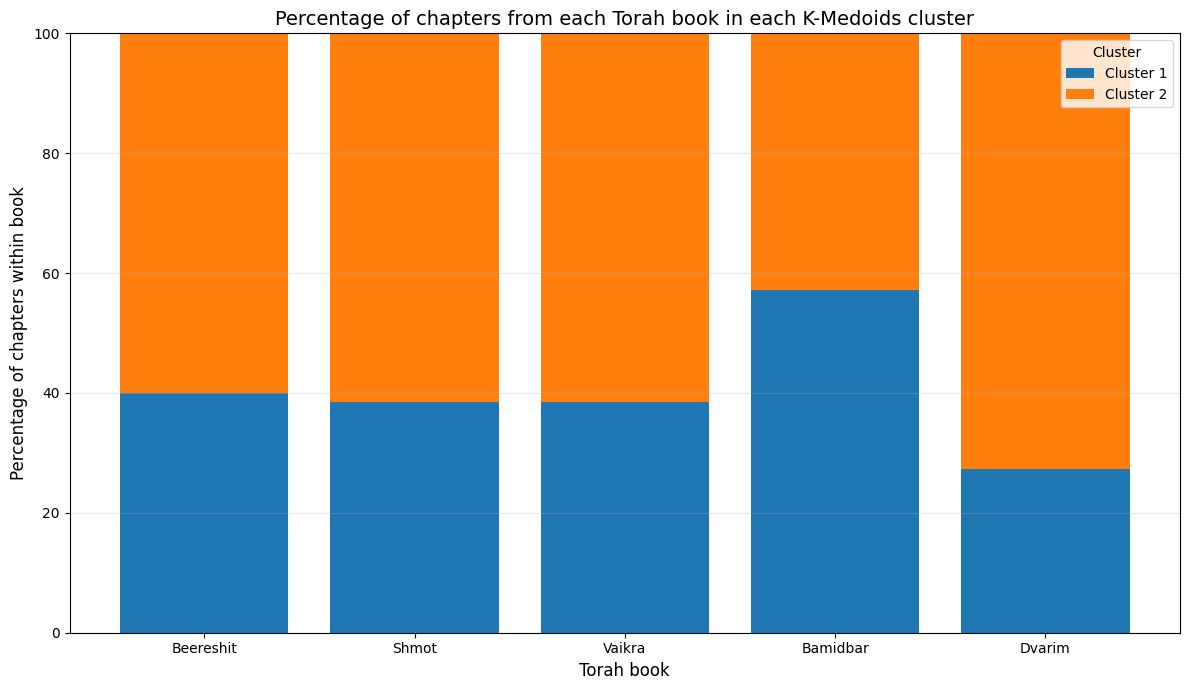

Percentage of chapters from each book in each cluster:


straight_label,1,2
book,,
Beereshit,40.00,60.00
Shmot,38.46,61.54
Vaikra,38.46,61.54
Bamidbar,57.14,42.86
Dvarim,27.27,72.73


Chapter counts from each book in each cluster:


straight_label,1,2
book,,
Beereshit,20,30
Shmot,15,24
Vaikra,10,16
Bamidbar,20,15
Dvarim,9,24


In [6]:
# ============================================================
# Cell 4:
# Stacked Bar Chart
# Percentage of chapters from each book in each cluster
#
# Goal:
# Show, for each Torah book, what percentage of its chapters belongs to each cluster.
#
# X axis = book names
# Y axis = percentage within the book chapters
# Each segment in a bar = another cluster
# ============================================================

if "analysis_df" not in globals():
    raise RuntimeError("analysis_df was not found. Run Cell 1 first.")

if "straight_label" not in analysis_df.columns:
    raise RuntimeError("The straight_label column was not found in analysis_df. Run Cell 1 first.")


# ------------------------------------------------------------
# Book order as it appears in the Torah
# ------------------------------------------------------------

TORAH_BOOK_ORDER = [
    "Beereshit",
    "Shmot",
    "Vaikra",
    "Bamidbar",
    "Dvarim"
]


# ------------------------------------------------------------
# Count how many chapters from each book are in each cluster
# ------------------------------------------------------------

cluster_counts_by_book = (
    analysis_df
    .groupby(["book", "straight_label"])
    .size()
    .unstack(fill_value=0)
)


# ------------------------------------------------------------
# Sort by Torah order
# Books that are not present in the data are simply not displayed
# ------------------------------------------------------------

existing_books_in_order = [
    book for book in TORAH_BOOK_ORDER
    if book in cluster_counts_by_book.index
]

cluster_counts_by_book = cluster_counts_by_book.loc[existing_books_in_order]


# ------------------------------------------------------------
# Convert counts into percentages within each book
# ------------------------------------------------------------

cluster_percent_by_book = (
    cluster_counts_by_book
    .div(cluster_counts_by_book.sum(axis=1), axis=0)
    * 100
)


# ------------------------------------------------------------
# Draw the stacked bar chart
# ------------------------------------------------------------

plt.figure(figsize=(12, 7))

bottom = np.zeros(len(cluster_percent_by_book))

for cluster_label in sorted(cluster_percent_by_book.columns):

    values = cluster_percent_by_book[cluster_label].values

    plt.bar(
        cluster_percent_by_book.index,
        values,
        bottom=bottom,
        label=f"Cluster {cluster_label}"
    )

    bottom += values


plt.title(
    "Percentage of chapters from each Torah book in each K-Medoids cluster",
    fontsize=14
)

plt.xlabel("Torah book", fontsize=12)
plt.ylabel("Percentage of chapters within book", fontsize=12)

plt.ylim(0, 100)
plt.legend(title="Cluster")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Helper table: percentages
# ------------------------------------------------------------

print("Percentage of chapters from each book in each cluster:")
display(cluster_percent_by_book.round(2))


# ------------------------------------------------------------
# Helper table: actual counts
# ------------------------------------------------------------

print("Chapter counts from each book in each cluster:")
display(cluster_counts_by_book)

/tmp/ipykernel_1248/2540192569.py:217: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


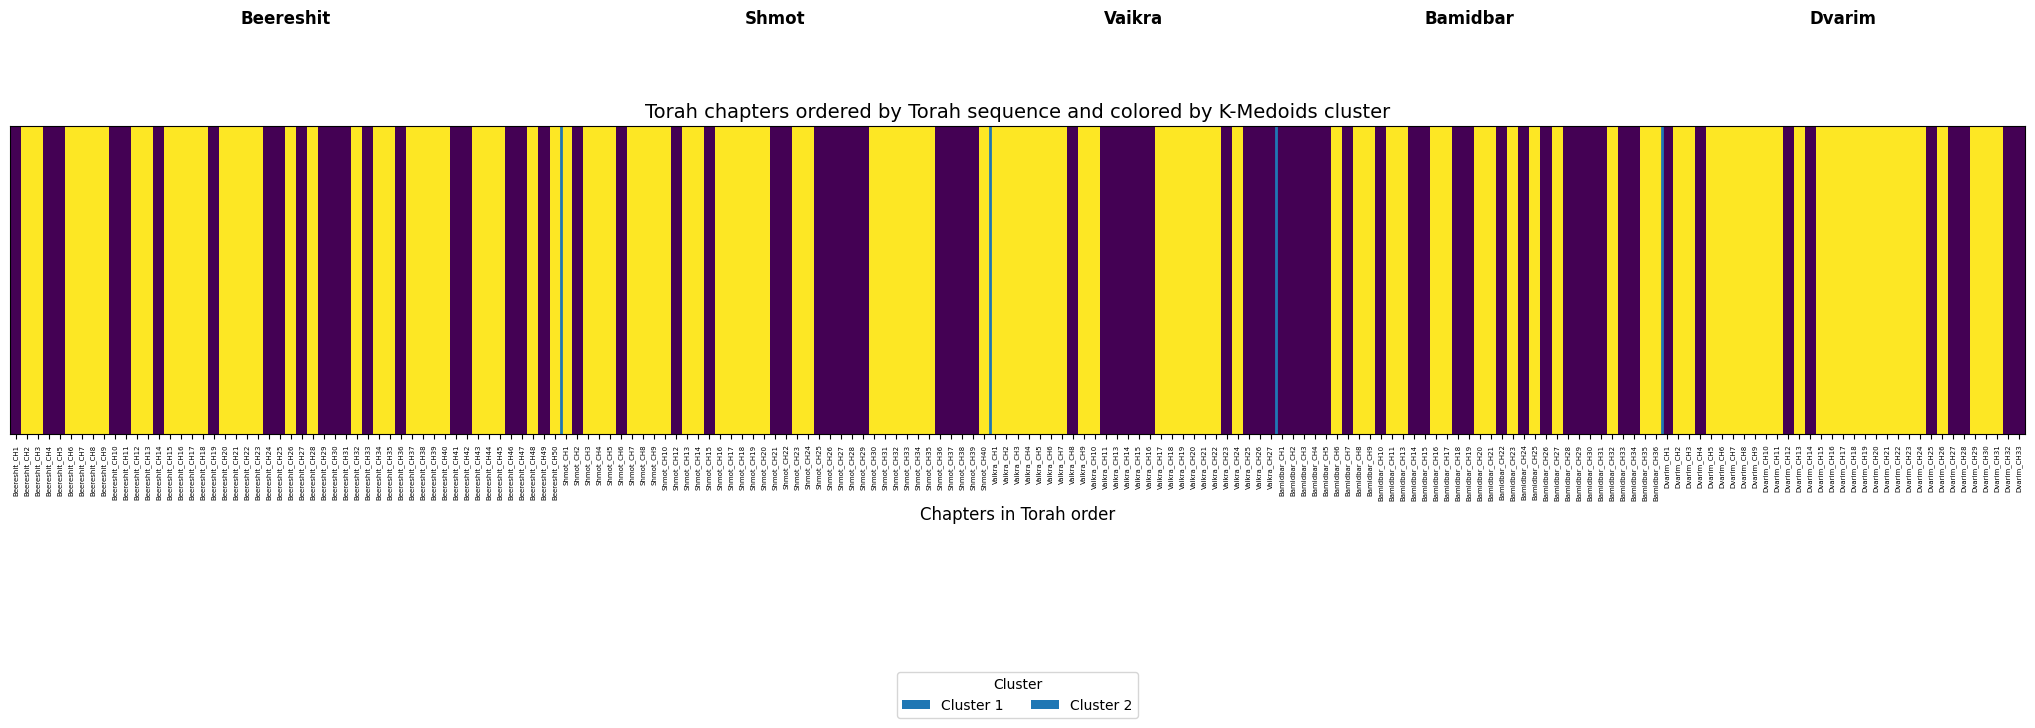

,chapter,book,chapter_number,straight_label,negative_count,negative_ratio,mean_anomaly_score
0,Beereshit_CH1,Beereshit,1,1,17,0.188889,0.048260
1,Beereshit_CH2,Beereshit,2,2,11,0.122222,0.071884
2,Beereshit_CH3,Beereshit,3,2,10,0.111111,0.077517
3,Beereshit_CH4,Beereshit,4,1,5,0.055556,0.075201
4,Beereshit_CH5,Beereshit,5,1,18,0.200000,0.062005
...,...,...,...,...,...,...,...
178,Dvarim_CH29,Dvarim,29,2,0,0.000000,0.104469
179,Dvarim_CH30,Dvarim,30,2,4,0.044444,0.106085
180,Dvarim_CH31,Dvarim,31,2,7,0.077778,0.090180
181,Dvarim_CH32,Dvarim,32,1,45,0.500000,-0.031047


In [7]:
# ============================================================
# Cell 5:
# Chapter strip along the Torah
# Each chapter is colored by its cluster
#
# Goal:
# Display all chapters in their Torah order:
# Beereshit → Shmot → Vaikra → Bamidbar → Dvarim
#
# Within each book:
# By chapter number, for example Beereshit_CH01, Beereshit_CH02, and so on.
#
# Output:
# heatmap / horizontal strip
# X axis = chapters in Torah order
# Y axis = one row
# Color = cluster
# Vertical lines = book boundaries
# ============================================================

if "analysis_df" not in globals():
    raise RuntimeError("analysis_df was not found. Run Cell 1 first.")

if "straight_label" not in analysis_df.columns:
    raise RuntimeError("The straight_label column was not found in analysis_df. Run Cell 1 first.")


# ------------------------------------------------------------
# Book order as it appears in the Torah
# ------------------------------------------------------------

TORAH_BOOK_ORDER = [
    "Beereshit",
    "Shmot",
    "Vaikra",
    "Bamidbar",
    "Dvarim"
]

BOOK_ORDER_MAP = {
    book_name: index
    for index, book_name in enumerate(TORAH_BOOK_ORDER)
}


# ------------------------------------------------------------
# Extract the chapter number from the chapter name
#
# Examples:
# Beereshit_CH01 -> 1
# Shmot_CH12     -> 12
# Bamidbar_CH7   -> 7
#
# If no chapter number is found, return a large number so it appears at the end of the book.
# ------------------------------------------------------------

def extract_chapter_number(chapter_name):
    chapter_name = str(chapter_name)

    match = re.search(r"_CH0*(\d+)", chapter_name)

    if match:
        return int(match.group(1))

    # fallback:
    # If the name happens to contain any number without CH
    match = re.search(r"(\d+)", chapter_name)

    if match:
        return int(match.group(1))

    return 10**9


# ------------------------------------------------------------
# Build a DataFrame sorted by Torah order
# ------------------------------------------------------------

torah_order_df = analysis_df.copy()

torah_order_df["book_order"] = torah_order_df["book"].map(BOOK_ORDER_MAP)
torah_order_df["chapter_number"] = torah_order_df["chapter"].apply(extract_chapter_number)

# If a book is not recognized, it is moved to the end
torah_order_df["book_order"] = torah_order_df["book_order"].fillna(10**9)

torah_order_df = (
    torah_order_df
    .sort_values(["book_order", "chapter_number", "chapter"])
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Prepare a one-row matrix
# Each cell is the chapter cluster
# ------------------------------------------------------------

cluster_strip = torah_order_df["straight_label"].to_numpy().reshape(1, -1)
chapter_labels_ordered = torah_order_df["chapter"].to_numpy()


# ------------------------------------------------------------
# Compute boundaries between books
# ------------------------------------------------------------

book_sizes = (
    torah_order_df
    .groupby("book", sort=False)
    .size()
)

book_boundaries = []
book_centers = []
book_names_for_plot = []

start_index = 0

for book_name, size in book_sizes.items():

    end_index = start_index + size

    center = start_index + (size - 1) / 2

    book_centers.append(center)
    book_names_for_plot.append(book_name)

    # Boundary after the book
    book_boundaries.append(end_index - 0.5)

    start_index = end_index


# ------------------------------------------------------------
# Draw the strip
# ------------------------------------------------------------

plt.figure(figsize=(26, 4))

plt.imshow(
    cluster_strip,
    aspect="auto",
    interpolation="nearest"
)

plt.title(
    "Torah chapters ordered by Torah sequence and colored by K-Medoids cluster",
    fontsize=14
)

plt.xlabel("Chapters in Torah order", fontsize=12)
plt.yticks([])


# ------------------------------------------------------------
# Display chapter names on the X axis
# Reduce or disable this if it is too crowded
# ------------------------------------------------------------

plt.xticks(
    ticks=np.arange(len(chapter_labels_ordered)),
    labels=chapter_labels_ordered,
    rotation=90,
    fontsize=5
)


# ------------------------------------------------------------
# Vertical lines between books
# Do not draw the final boundary at the end of the Torah
# ------------------------------------------------------------

for boundary in book_boundaries[:-1]:
    plt.axvline(
        boundary,
        linewidth=2
    )


# ------------------------------------------------------------
# Book names above their regions
# ------------------------------------------------------------

for center, book_name in zip(book_centers, book_names_for_plot):
    plt.text(
        center,
        -0.85,
        book_name,
        ha="center",
        va="center",
        fontsize=12,
        fontweight="bold"
    )


# ------------------------------------------------------------
# Manual legend for the clusters
# ------------------------------------------------------------

from matplotlib.patches import Patch

unique_clusters = sorted(torah_order_df["straight_label"].unique())

legend_handles = [
    Patch(label=f"Cluster {cluster_label}")
    for cluster_label in unique_clusters
]

plt.legend(
    handles=legend_handles,
    title="Cluster",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.75),
    ncol=len(unique_clusters)
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Helper table: chapter order and assigned cluster
# ------------------------------------------------------------

display(
    torah_order_df[
        ["chapter", "book", "chapter_number", "straight_label", "negative_count", "negative_ratio", "mean_anomaly_score"]
    ]
)

Note: adjustText is not installed. To enable automatic label adjustment, run:
!pip install adjustText


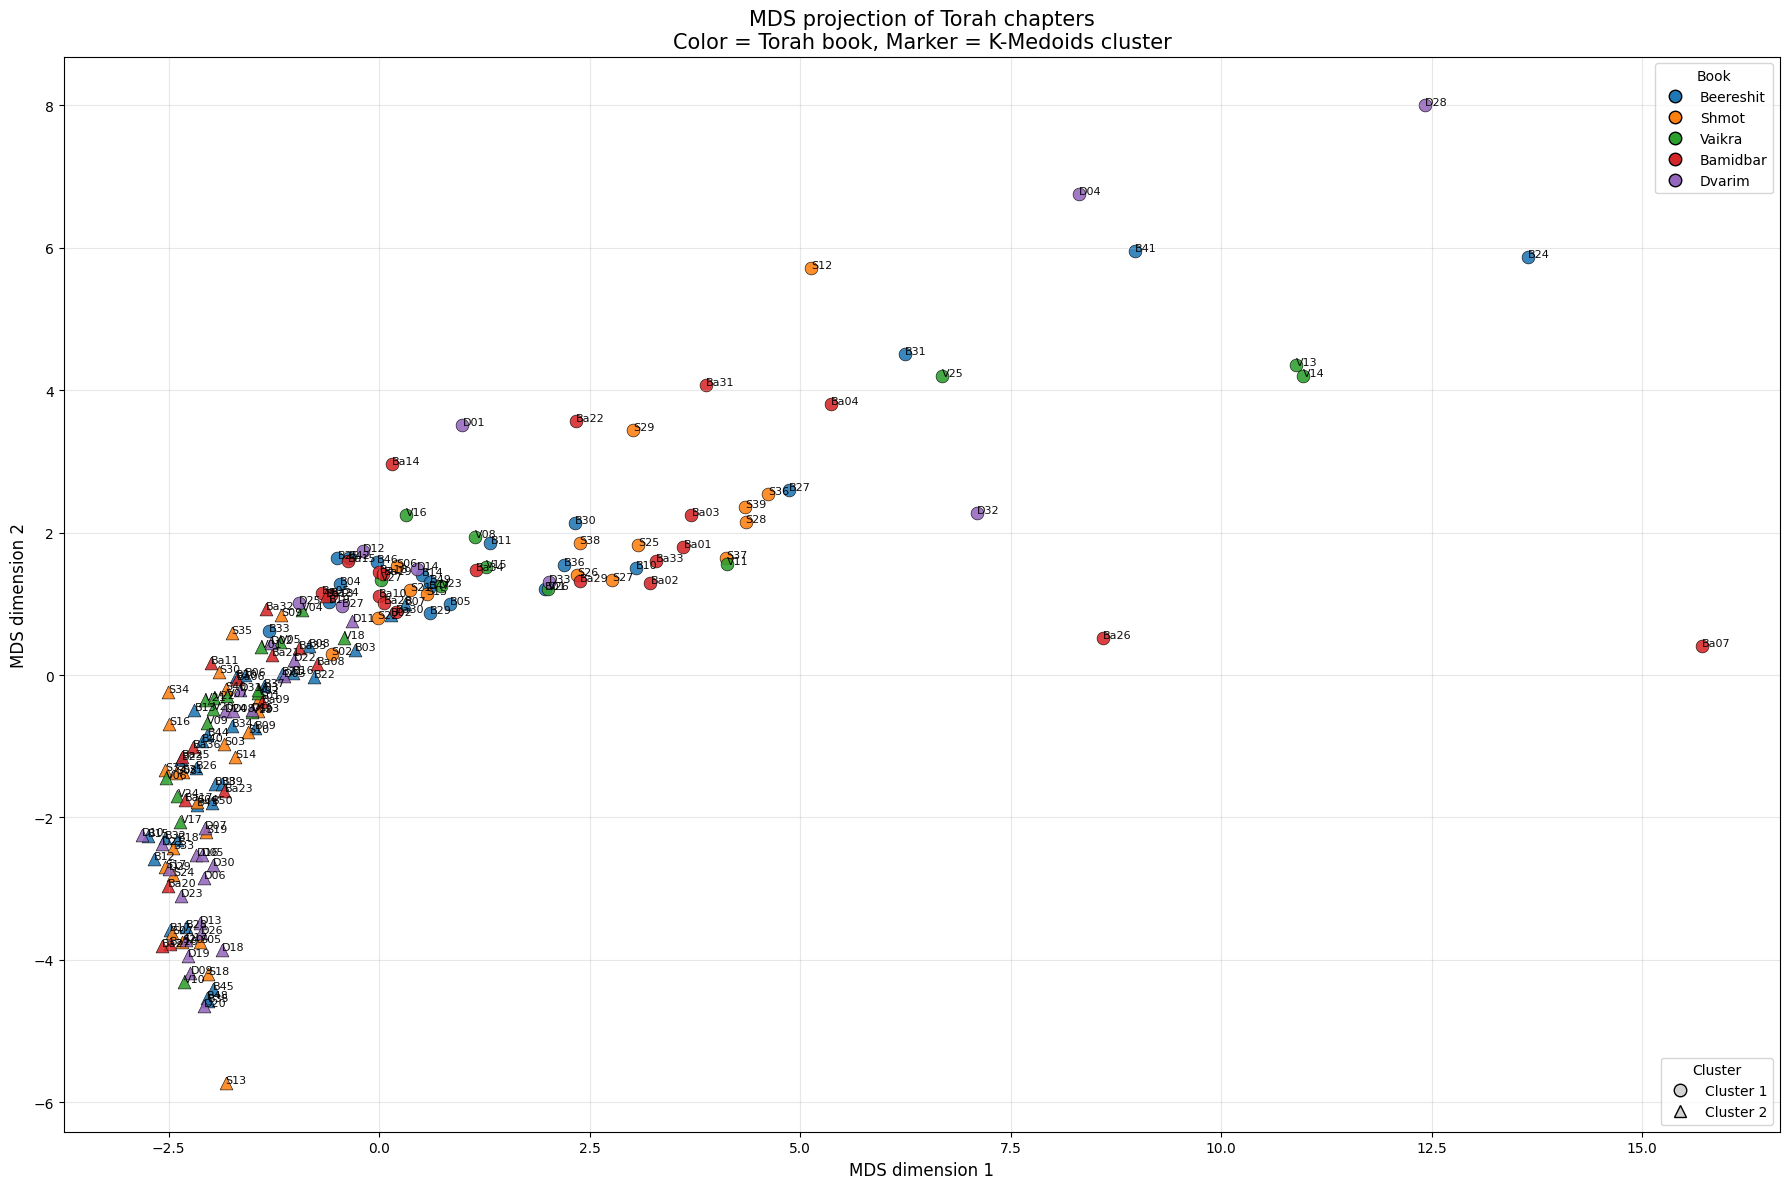

Full MDS table:


,chapter,book,straight_label,mds_x,mds_y,short_label
0,Bamidbar_CH1,Bamidbar,1,3.613916,1.802487,Ba01
1,Bamidbar_CH10,Bamidbar,1,-0.002272,1.110078,Ba10
2,Bamidbar_CH11,Bamidbar,2,-2.002663,0.175539,Ba11
3,Bamidbar_CH13,Bamidbar,2,-0.631476,1.106826,Ba13
4,Bamidbar_CH14,Bamidbar,1,0.152592,2.963911,Ba14
...,...,...,...,...,...,...
178,Vaikra_CH5,Vaikra,2,-1.173431,0.464505,V05
179,Vaikra_CH6,Vaikra,2,-2.532197,-1.442583,V06
180,Vaikra_CH7,Vaikra,2,-1.810053,-0.291071,V07
181,Vaikra_CH8,Vaikra,1,1.139277,1.934275,V08



The densest region detected on the X axis:
X from -2.819 to 1.813
Number of points in this region: 146 out of 183
Percentage of points: 79.78%
Search-window width: 25.0% of the total X range


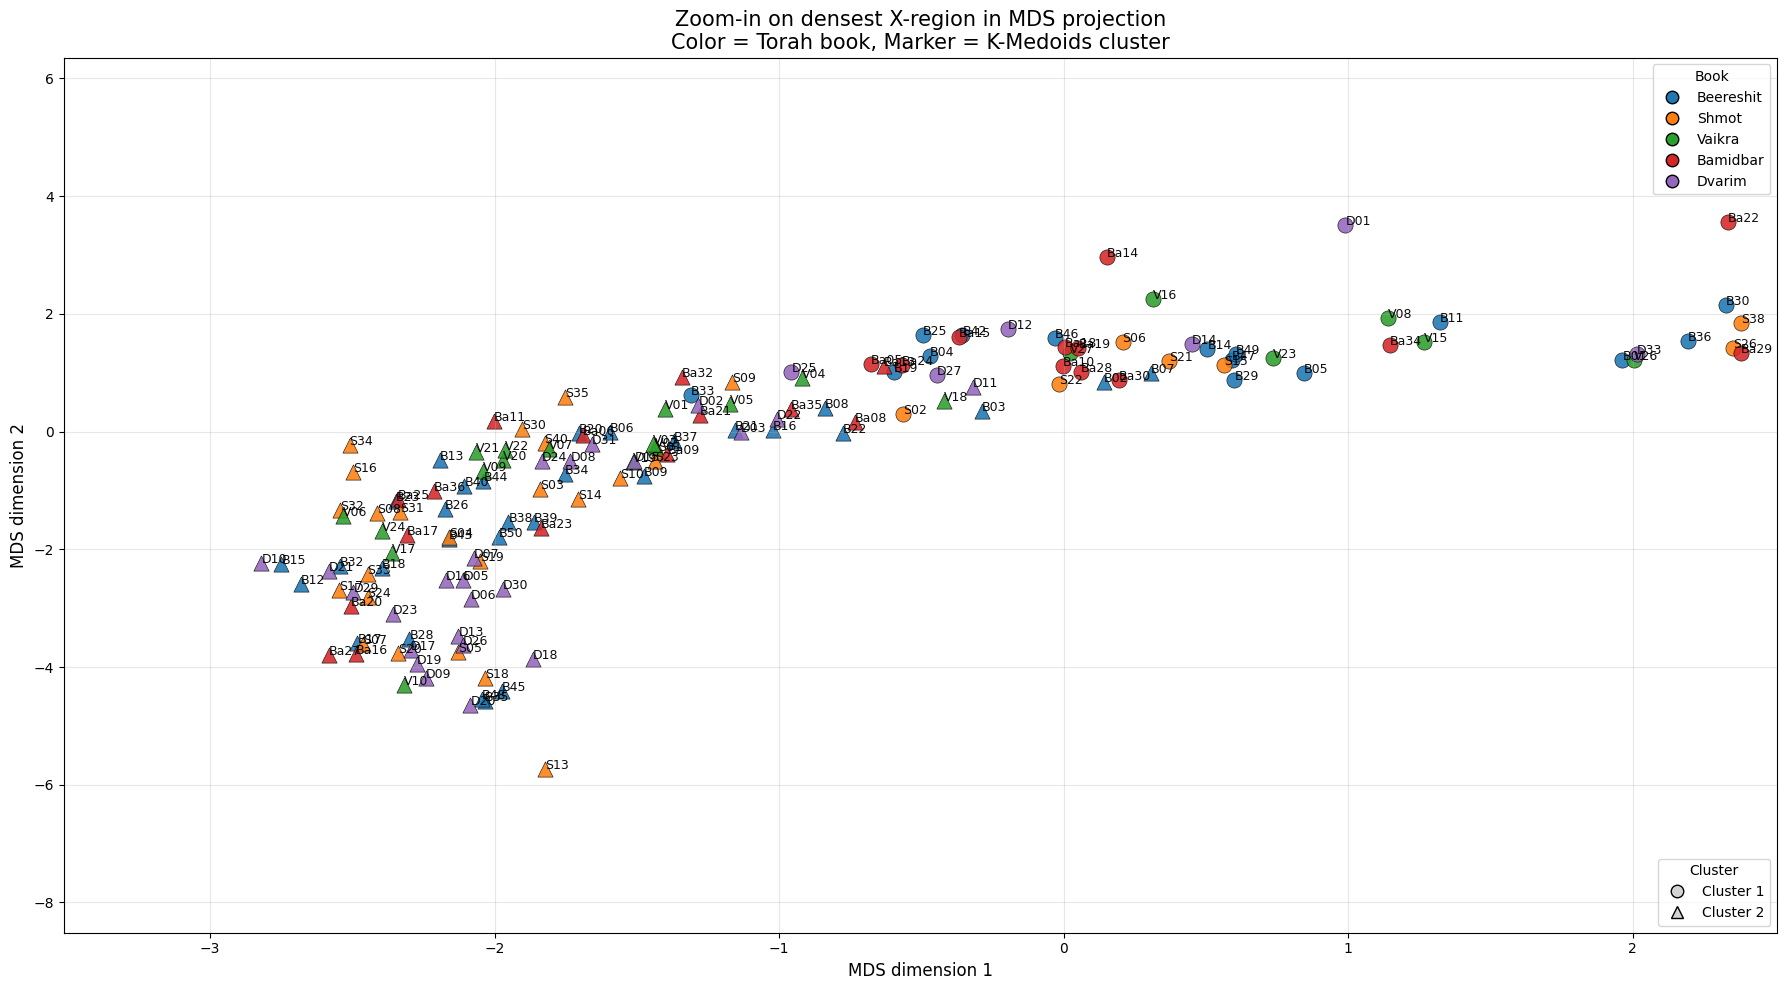

Chapters located in the dense region:


,chapter,book,straight_label,mds_x,mds_y,short_label
86,Dvarim_CH10,Dvarim,2,-2.819015,-2.239490,D10
41,Beereshit_CH15,Beereshit,2,-2.749137,-2.254499,B15
38,Beereshit_CH12,Beereshit,2,-2.679534,-2.588543,B12
98,Dvarim_CH21,Dvarim,2,-2.582440,-2.377505,D21
18,Bamidbar_CH27,Bamidbar,2,-2.581867,-3.799930,Ba27
...,...,...,...,...,...,...
58,Beereshit_CH30,Beereshit,1,2.327669,2.142224,B30
13,Bamidbar_CH22,Bamidbar,1,2.332800,3.565649,Ba22
135,Shmot_CH26,Shmot,1,2.353153,1.411707,S26
148,Shmot_CH38,Shmot,1,2.379571,1.850688,S38


In [8]:
# ============================================================
# Cell 6:
# MDS Scatter Plot + Zoom-in to the densest region
#
# Each point = chapter
# Color = book
# Marker shape = cluster
#
# Plot 1:
#   Full MDS over all chapters
#
# Plot 2:
#   Automatically identify the densest region on the X axis
#   and draw a zoom-in only for that region
#
# Required before this cell:
#   analysis_df
#   full_distance_matrix
#   straight_labels
# ============================================================


# ============================================================
# Preliminary checks
# ============================================================

if "analysis_df" not in globals():
    raise RuntimeError("analysis_df was not found. Run Cell 1 first.")

if "full_distance_matrix" not in globals():
    raise RuntimeError("full_distance_matrix was not found. Run Cell 1 first.")

if "straight_labels" not in globals():
    raise RuntimeError("straight_labels were not found. Run Cell 1 first.")

required_columns = ["chapter", "book", "straight_label"]

for col in required_columns:
    if col not in analysis_df.columns:
        raise RuntimeError(f"Column {col} was not found in analysis_df.")


# ============================================================
# imports
# ============================================================

import re
import numpy as np
import matplotlib.pyplot as plt

from sklearn.manifold import MDS
from matplotlib.lines import Line2D


# ------------------------------------------------------------
# adjustText is optional.
# If it is not installed, the code will still run,
# but labels will not be adjusted automatically.
#
# If needed:
# !pip install adjustText
# ------------------------------------------------------------

try:
    from adjustText import adjust_text
    ADJUST_TEXT_AVAILABLE = True
except ImportError:
    ADJUST_TEXT_AVAILABLE = False
    print("Note: adjustText is not installed. To enable automatic label adjustment, run:")
    print("!pip install adjustText")


# ============================================================
# General settings
# ============================================================

MDS_RANDOM_STATE = 42

MAIN_FIGSIZE = (18, 12)
ZOOM_FIGSIZE = (18, 10)

SHOW_ALL_POINT_LABELS = True

# Whether to enable automatic label adjustment in the main plot
# If there are many chapters, this can take some time.
ADJUST_LABELS_IN_MAIN_GRAPH = False

# Whether to enable automatic label adjustment in the zoom plot
ADJUST_LABELS_IN_ZOOM_GRAPH = True

# Dense-region size:
# 0.25 = search a window whose width is 25% of the total X range
DENSE_WINDOW_PERCENT = 0.25

# How much padding to add around the dense region after it is found
DENSE_X_PADDING_PERCENT = 0.15
DENSE_Y_PADDING_PERCENT = 0.30

# Point size
MAIN_POINT_SIZE = 85
ZOOM_POINT_SIZE = 120

# Text size
MAIN_LABEL_FONT_SIZE = 8
ZOOM_LABEL_FONT_SIZE = 9


# ============================================================
# Color and marker mapping
# ============================================================

# Marker by cluster
CLUSTER_MARKERS = {
    1: "o",   # suspicious / smaller cluster
    2: "^"    # core / larger cluster
}

# Color by book
BOOK_COLORS = {
    "Beereshit": "C0",
    "Shmot": "C1",
    "Vaikra": "C2",
    "Bamidbar": "C3",
    "Dvarim": "C4"
}

TORAH_BOOK_ORDER = [
    "Beereshit",
    "Shmot",
    "Vaikra",
    "Bamidbar",
    "Dvarim"
]


# ============================================================
# Helper functions
# ============================================================

def short_chapter_label(chapter_name: str) -> str:
    """
    Creates a short chapter label to reduce clutter on the plot.

    Examples:
    Beereshit_CH01 -> B01
    Shmot_CH12     -> S12
    Vaikra_CH7     -> V07
    Bamidbar_CH04  -> Ba04
    Dvarim_CH03    -> D03
    """

    chapter_name = str(chapter_name)

    if "_CH" in chapter_name:
        book_name, chapter_part = chapter_name.split("_CH", 1)

        chapter_digits = re.sub(r"\D", "", chapter_part)
        chapter_num = int(chapter_digits) if chapter_digits else 0

        short_book_map = {
            "Beereshit": "B",
            "Shmot": "S",
            "Vaikra": "V",
            "Bamidbar": "Ba",
            "Dvarim": "D"
        }

        short_book = short_book_map.get(book_name, book_name[:2])

        return f"{short_book}{chapter_num:02d}"

    return chapter_name[:10]


def find_densest_x_window(plot_df, x_col="mds_x", window_percent=0.25):
    """
    Finds the X segment containing the highest number of points.

    Example:
    If the X axis ranges from 0 to 20,
    and window_percent = 0.25,
    then the window width will be 5.

    The function slides this window along the X axis,
    and checks which window contains the most chapters.
    """

    x_values = np.sort(plot_df[x_col].to_numpy())

    x_min = x_values.min()
    x_max = x_values.max()
    x_range = x_max - x_min

    window_width = x_range * window_percent

    if window_width <= 0:
        return x_min, x_max, len(x_values)

    best_start = x_min
    best_end = x_min + window_width
    best_count = 0

    for start in x_values:
        end = start + window_width

        count = np.sum((x_values >= start) & (x_values <= end))

        if count > best_count:
            best_count = count
            best_start = start
            best_end = end

    return best_start, best_end, best_count


def draw_mds_scatter(
    df,
    title,
    figsize,
    point_size,
    label_font_size,
    adjust_labels=False,
    xlim=None,
    ylim=None
):
    """
    Draws an MDS scatter plot.

    Color = book
    Marker shape = cluster
    """

    plt.figure(figsize=figsize)

    texts = []

    for book_name in book_values:

        book_color = BOOK_COLORS.get(book_name, "gray")

        for cluster_label in cluster_values:

            marker_style = CLUSTER_MARKERS.get(cluster_label, "o")

            subset = df[
                (df["book"] == book_name) &
                (df["straight_label"] == cluster_label)
            ]

            if len(subset) == 0:
                continue

            plt.scatter(
                subset["mds_x"],
                subset["mds_y"],
                marker=marker_style,
                c=book_color,
                s=point_size,
                alpha=0.88,
                edgecolors="black",
                linewidths=0.45
            )

    # --------------------------------------------------------
    # labels
    # --------------------------------------------------------

    if SHOW_ALL_POINT_LABELS:

        for _, row in df.iterrows():

            text = plt.text(
                row["mds_x"],
                row["mds_y"],
                row["short_label"],
                fontsize=label_font_size,
                alpha=0.95
            )

            texts.append(text)

        if adjust_labels and ADJUST_TEXT_AVAILABLE:
            adjust_text(
                texts,
                expand_points=(1.4, 1.7),
                expand_text=(1.3, 1.6),
                force_text=(0.4, 0.7),
                force_points=(0.3, 0.5),
                arrowprops=dict(
                    arrowstyle="-",
                    lw=0.4,
                    alpha=0.5
                )
            )

    # --------------------------------------------------------
    # Axis limits
    # --------------------------------------------------------

    if xlim is not None:
        plt.xlim(xlim[0], xlim[1])

    if ylim is not None:
        plt.ylim(ylim[0], ylim[1])

    # --------------------------------------------------------
    # Titles and axes
    # --------------------------------------------------------

    plt.title(title, fontsize=15)
    plt.xlabel("MDS dimension 1", fontsize=12)
    plt.ylabel("MDS dimension 2", fontsize=12)
    plt.grid(alpha=0.3)

    # --------------------------------------------------------
    # legends
    # --------------------------------------------------------

    legend_books = plt.legend(
        handles=book_legend_handles,
        title="Book",
        loc="upper right"
    )

    plt.gca().add_artist(legend_books)

    plt.legend(
        handles=cluster_legend_handles,
        title="Cluster",
        loc="lower right"
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# Run MDS on the distance matrix
# ============================================================

mds = MDS(
    n_components=2,
    dissimilarity="precomputed",
    random_state=MDS_RANDOM_STATE
)

mds_coordinates = mds.fit_transform(full_distance_matrix)


# ============================================================
# Build a DataFrame for plotting
# ============================================================

plot_df = analysis_df.copy()

plot_df["mds_x"] = mds_coordinates[:, 0]
plot_df["mds_y"] = mds_coordinates[:, 1]
plot_df["short_label"] = plot_df["chapter"].apply(short_chapter_label)


# ============================================================
# Existing values in the data
# ============================================================

book_values = [
    book for book in TORAH_BOOK_ORDER
    if book in plot_df["book"].unique()
]

cluster_values = sorted(plot_df["straight_label"].unique())


# ============================================================
# legends
# ============================================================

book_legend_handles = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="",
        markersize=9,
        label=book_name,
        markerfacecolor=BOOK_COLORS.get(book_name, "gray"),
        markeredgecolor="black",
        color="black"
    )
    for book_name in book_values
]

cluster_legend_handles = [
    Line2D(
        [0], [0],
        marker=CLUSTER_MARKERS.get(cluster_label, "o"),
        linestyle="",
        markersize=9,
        label=f"Cluster {cluster_label}",
        markerfacecolor="lightgray",
        markeredgecolor="black",
        color="black"
    )
    for cluster_label in cluster_values
]


# ============================================================
# Plot 1:
# Full MDS
# ============================================================

draw_mds_scatter(
    df=plot_df,
    title=(
        "MDS projection of Torah chapters\n"
        "Color = Torah book, Marker = K-Medoids cluster"
    ),
    figsize=MAIN_FIGSIZE,
    point_size=MAIN_POINT_SIZE,
    label_font_size=MAIN_LABEL_FONT_SIZE,
    adjust_labels=ADJUST_LABELS_IN_MAIN_GRAPH
)


# ============================================================
# General helper table
# ============================================================

print("Full MDS table:")
display(
    plot_df[
        ["chapter", "book", "straight_label", "mds_x", "mds_y", "short_label"]
    ].sort_values(["book", "chapter"])
)


# ============================================================
# Identify the densest region on the X axis
# ============================================================

dense_x_start, dense_x_end, dense_count = find_densest_x_window(
    plot_df,
    x_col="mds_x",
    window_percent=DENSE_WINDOW_PERCENT
)

x_width = dense_x_end - dense_x_start
x_padding = x_width * DENSE_X_PADDING_PERCENT

zoom_x_min = dense_x_start - x_padding
zoom_x_max = dense_x_end + x_padding

zoom_df = plot_df[
    (plot_df["mds_x"] >= zoom_x_min) &
    (plot_df["mds_x"] <= zoom_x_max)
].copy()


# ============================================================
# Y limits for the zoom
# ============================================================

if len(zoom_df) > 0:

    y_min = zoom_df["mds_y"].min()
    y_max = zoom_df["mds_y"].max()
    y_range = y_max - y_min

    if y_range == 0:
        y_range = 1

    y_padding = y_range * DENSE_Y_PADDING_PERCENT

    zoom_y_min = y_min - y_padding
    zoom_y_max = y_max + y_padding

else:
    raise RuntimeError("No points were found in the zoom region. Try increasing DENSE_WINDOW_PERCENT.")


# ============================================================
# Text output for the dense region
# ============================================================

print("\nThe densest region detected on the X axis:")
print(f"X from {dense_x_start:.3f} to {dense_x_end:.3f}")
print(f"Number of points in this region: {dense_count} out of {len(plot_df)}")
print(f"Percentage of points: {100 * dense_count / len(plot_df):.2f}%")
print(f"Search-window width: {DENSE_WINDOW_PERCENT * 100:.1f}% of the total X range")


# ============================================================
# Plot 2:
# Zoom-in on the densest region
# ============================================================

draw_mds_scatter(
    df=zoom_df,
    title=(
        "Zoom-in on densest X-region in MDS projection\n"
        "Color = Torah book, Marker = K-Medoids cluster"
    ),
    figsize=ZOOM_FIGSIZE,
    point_size=ZOOM_POINT_SIZE,
    label_font_size=ZOOM_LABEL_FONT_SIZE,
    adjust_labels=ADJUST_LABELS_IN_ZOOM_GRAPH,
    xlim=(zoom_x_min, zoom_x_max),
    ylim=(zoom_y_min, zoom_y_max)
)


# ============================================================
# Helper table of points in the dense region
# ============================================================

print("Chapters located in the dense region:")
display(
    zoom_df[
        ["chapter", "book", "straight_label", "mds_x", "mds_y", "short_label"]
    ].sort_values(["mds_x", "mds_y"])
)

Book-to-book distance matrix using mean:


,Beereshit,Shmot,Vaikra,Bamidbar,Dvarim
Beereshit,4.3432,3.8022,3.8076,3.8981,4.3050
Shmot,3.8022,4.0506,4.2677,4.3526,4.3036
Vaikra,3.8076,4.2677,4.9092,4.5131,4.5498
Bamidbar,3.8981,4.3526,4.5131,4.7503,4.6660
Dvarim,4.3050,4.3036,4.5498,4.6660,5.0090


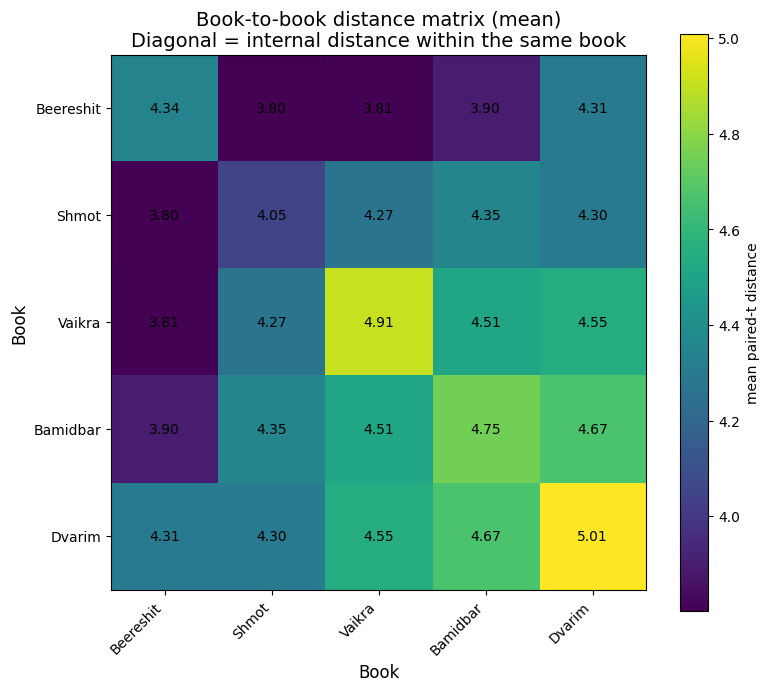

Brief interpretation:
The diagonal shows the internal distance between different chapters within the same book.
Off-diagonal cells show the distance between chapters from two different books.
A higher value means the pattern between books/chapters is more different according to the paired-t matrix.


In [9]:
# ============================================================
# Cell 7:
# Book-to-book distance matrix
#
# Goal:
# Convert the chapter-level distance matrix
# into a book-level distance matrix.
#
# For each pair of books:
#   take all distances between chapters of book A and chapters of book B
#   and compute the mean or median.
#
# On the diagonal:
#   compute the internal distance inside the same book,
#   meaning only between different chapters in that same book,
#   excluding the self-diagonal where the distance is 0.
#
# Required before this cell:
#   analysis_df
#   full_distance_matrix
# ============================================================


# ============================================================
# Preliminary checks
# ============================================================

if "analysis_df" not in globals():
    raise RuntimeError("analysis_df was not found. Run Cell 1 first.")

if "full_distance_matrix" not in globals():
    raise RuntimeError("full_distance_matrix was not found. Run Cell 1 first.")

required_columns = ["chapter", "book"]

for col in required_columns:
    if col not in analysis_df.columns:
        raise RuntimeError(f"Column {col} was not found in analysis_df.")


# ============================================================
# imports
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# Settings
# ============================================================

TORAH_BOOK_ORDER = [
    "Beereshit",
    "Shmot",
    "Vaikra",
    "Bamidbar",
    "Dvarim"
]

# You can choose:
# "mean"   = mean
# "median" = median
BOOK_DISTANCE_AGGREGATION = "mean"

BOOK_DISTANCE_FIGSIZE = (8, 7)

SHOW_VALUES_ON_HEATMAP = True


# ============================================================
# Aggregation function
# ============================================================

def aggregate_distances(values, method="mean"):
    """
    Receives an array of distances and returns one value:
    mean or median.
    """

    values = np.asarray(values, dtype=float)

    # Remove NaN values if present
    values = values[~np.isnan(values)]

    if len(values) == 0:
        return np.nan

    if method == "mean":
        return np.mean(values)

    if method == "median":
        return np.median(values)

    raise ValueError("BOOK_DISTANCE_AGGREGATION must be 'mean' or 'median'.")


# ============================================================
# Prepare the list of books that actually exist
# ============================================================

existing_books = [
    book for book in TORAH_BOOK_ORDER
    if book in analysis_df["book"].unique()
]

if len(existing_books) == 0:
    raise RuntimeError("No books from TORAH_BOOK_ORDER were found in analysis_df['book'].")


# ============================================================
# Build the book-to-book distance matrix
# ============================================================

book_distance_matrix = pd.DataFrame(
    index=existing_books,
    columns=existing_books,
    dtype=float
)

book_indices = {
    book: analysis_df.index[analysis_df["book"] == book].to_numpy()
    for book in existing_books
}


for book_a in existing_books:

    indices_a = book_indices[book_a]

    for book_b in existing_books:

        indices_b = book_indices[book_b]

        distances_block = full_distance_matrix[np.ix_(indices_a, indices_b)]

        if book_a == book_b:
            # Inside the same book:
            # keep only distances between different chapters,
            # excluding the self-diagonal where each chapter is compared to itself = 0.
            if distances_block.shape[0] <= 1:
                values = np.array([])
            else:
                mask = ~np.eye(distances_block.shape[0], dtype=bool)
                values = distances_block[mask]
        else:
            # Between two different books:
            # take all distances between chapters of book A and chapters of book B.
            values = distances_block.flatten()

        book_distance_matrix.loc[book_a, book_b] = aggregate_distances(
            values,
            method=BOOK_DISTANCE_AGGREGATION
        )


# ============================================================
# Print the numeric table
# ============================================================

print(f"Book-to-book distance matrix using {BOOK_DISTANCE_AGGREGATION}:")
display(book_distance_matrix.round(4))


# ============================================================
# Draw the heatmap
# ============================================================

plt.figure(figsize=BOOK_DISTANCE_FIGSIZE)

plt.imshow(
    book_distance_matrix.values,
    aspect="equal"
)

plt.title(
    f"Book-to-book distance matrix ({BOOK_DISTANCE_AGGREGATION})\n"
    "Diagonal = internal distance within the same book",
    fontsize=14
)

plt.xlabel("Book", fontsize=12)
plt.ylabel("Book", fontsize=12)

plt.xticks(
    ticks=np.arange(len(existing_books)),
    labels=existing_books,
    rotation=45,
    ha="right"
)

plt.yticks(
    ticks=np.arange(len(existing_books)),
    labels=existing_books
)

plt.colorbar(label=f"{BOOK_DISTANCE_AGGREGATION} paired-t distance")


# ============================================================
# Add values inside the cells
# ============================================================

if SHOW_VALUES_ON_HEATMAP:

    for i in range(len(existing_books)):
        for j in range(len(existing_books)):

            value = book_distance_matrix.iloc[i, j]

            if np.isnan(value):
                text_value = "NaN"
            else:
                text_value = f"{value:.2f}"

            plt.text(
                j,
                i,
                text_value,
                ha="center",
                va="center",
                fontsize=10
            )


plt.tight_layout()
plt.show()


# ============================================================
# Brief interpretation
# ============================================================

print("Brief interpretation:")
print("The diagonal shows the internal distance between different chapters within the same book.")
print("Off-diagonal cells show the distance between chapters from two different books.")
print("A higher value means the pattern between books/chapters is more different according to the paired-t matrix.")

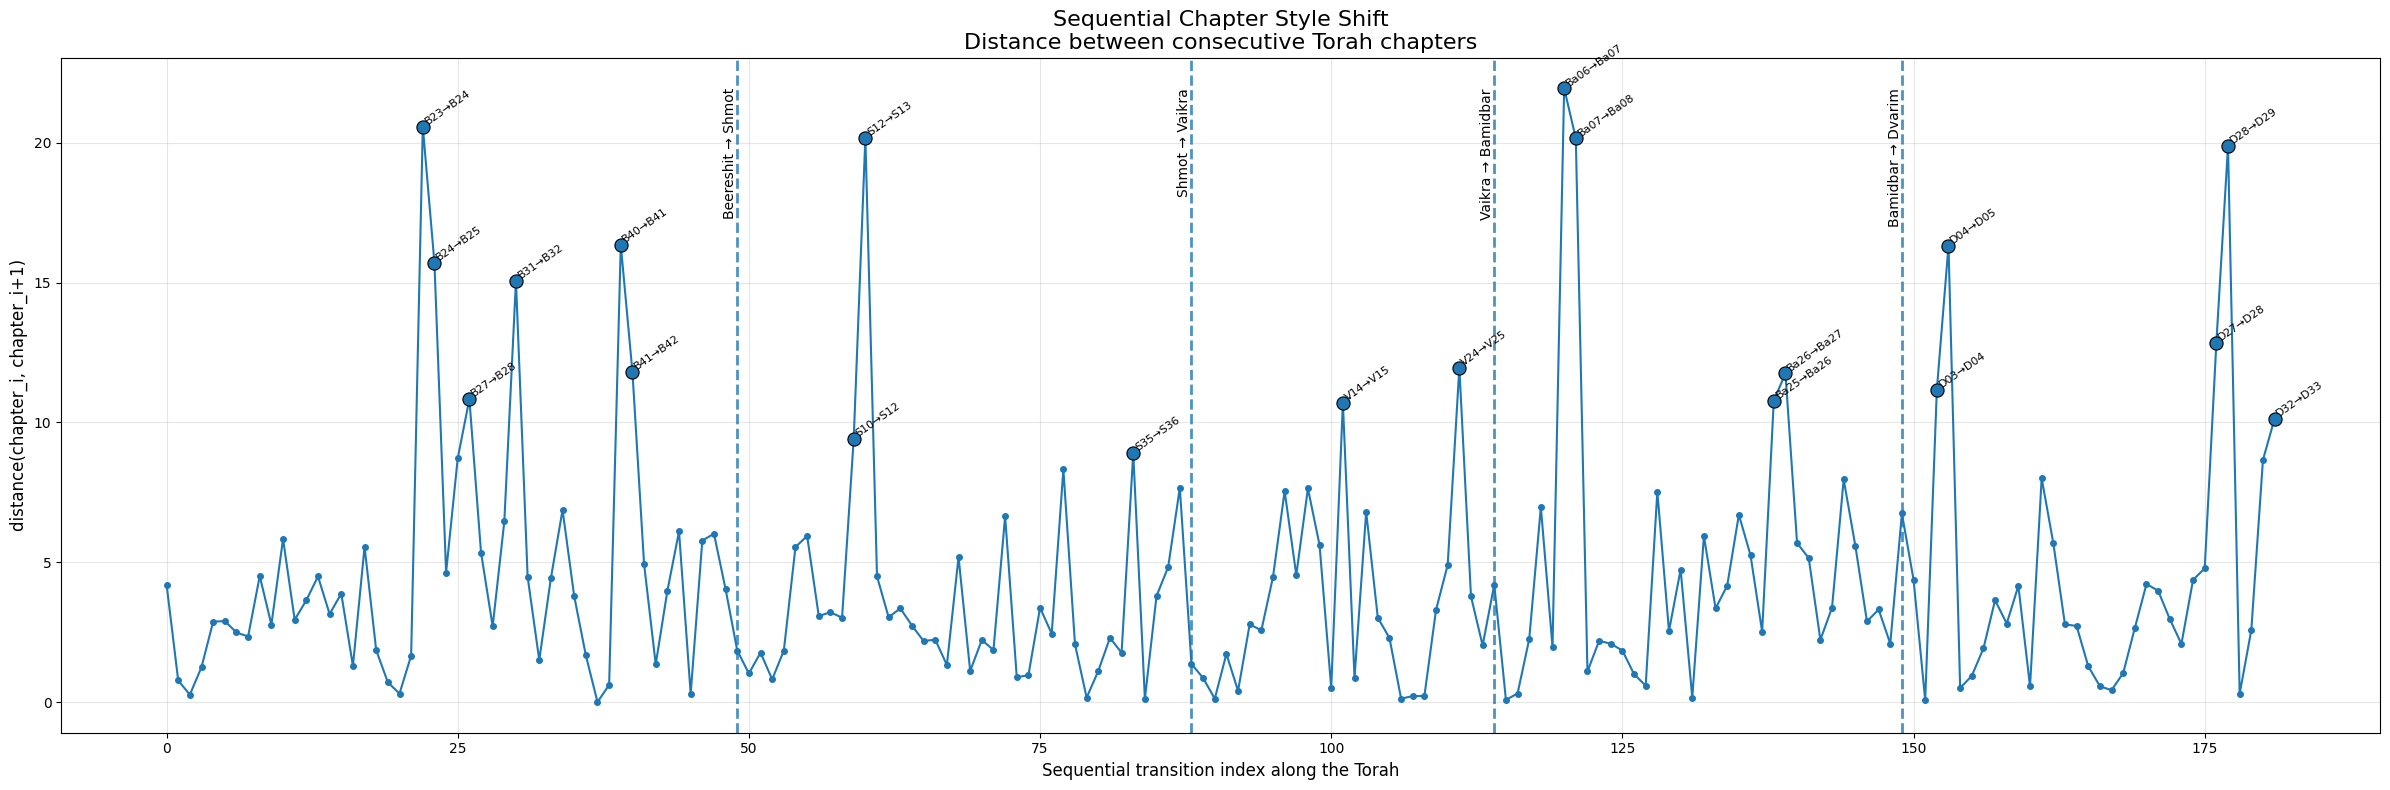

Top 20 sharpest sequential chapter transitions:


,transition_index,from_chapter,to_chapter,from_book,to_book,distance,is_book_boundary
0,120,Bamidbar_CH6,Bamidbar_CH7,Bamidbar,Bamidbar,21.944574,False
1,22,Beereshit_CH23,Beereshit_CH24,Beereshit,Beereshit,20.571676,False
2,60,Shmot_CH12,Shmot_CH13,Shmot,Shmot,20.179172,False
3,121,Bamidbar_CH7,Bamidbar_CH8,Bamidbar,Bamidbar,20.154943,False
4,177,Dvarim_CH28,Dvarim_CH29,Dvarim,Dvarim,19.876678,False
5,39,Beereshit_CH40,Beereshit_CH41,Beereshit,Beereshit,16.343768,False
6,153,Dvarim_CH4,Dvarim_CH5,Dvarim,Dvarim,16.317055,False
7,23,Beereshit_CH24,Beereshit_CH25,Beereshit,Beereshit,15.698341,False
8,30,Beereshit_CH31,Beereshit_CH32,Beereshit,Beereshit,15.056806,False
9,176,Dvarim_CH27,Dvarim_CH28,Dvarim,Dvarim,12.848979,False


All sequential transitions:


,transition_index,from_chapter,to_chapter,from_book,to_book,distance,is_book_boundary
0,0,Beereshit_CH1,Beereshit_CH2,Beereshit,Beereshit,4.206435,False
1,1,Beereshit_CH2,Beereshit_CH3,Beereshit,Beereshit,0.776826,False
2,2,Beereshit_CH3,Beereshit_CH4,Beereshit,Beereshit,0.268918,False
3,3,Beereshit_CH4,Beereshit_CH5,Beereshit,Beereshit,1.254106,False
4,4,Beereshit_CH5,Beereshit_CH6,Beereshit,Beereshit,2.878956,False
...,...,...,...,...,...,...,...
177,177,Dvarim_CH28,Dvarim_CH29,Dvarim,Dvarim,19.876678,False
178,178,Dvarim_CH29,Dvarim_CH30,Dvarim,Dvarim,0.300846,False
179,179,Dvarim_CH30,Dvarim_CH31,Dvarim,Dvarim,2.579639,False
180,180,Dvarim_CH31,Dvarim_CH32,Dvarim,Dvarim,8.660839,False


In [10]:
# ============================================================
# Cell 8:
# Sequential Chapter Style Shift
#
# Goal:
# Identify stylistic transition points along the Torah.
#
# For every pair of consecutive chapters in Torah order:
#   chapter_i -> chapter_i+1
#
# Compute:
#   distance(chapter_i, chapter_i+1)
#
# X axis = transition order along the Torah
# Y axis = distance between consecutive chapters
#
# Additionally:
#   - Vertical lines at book boundaries
#   - Table of the sharpest transitions
#
# Required before this cell:
#   analysis_df
#   full_distance_matrix
# ============================================================


# ============================================================
# Preliminary checks
# ============================================================

if "analysis_df" not in globals():
    raise RuntimeError("analysis_df was not found. Run Cell 1 first.")

if "full_distance_matrix" not in globals():
    raise RuntimeError("full_distance_matrix was not found. Run Cell 1 first.")

required_columns = ["chapter", "book"]

for col in required_columns:
    if col not in analysis_df.columns:
        raise RuntimeError(f"Column {col} was not found in analysis_df.")


# ============================================================
# imports
# ============================================================

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# Settings
# ============================================================

TORAH_BOOK_ORDER = [
    "Beereshit",
    "Shmot",
    "Vaikra",
    "Bamidbar",
    "Dvarim"
]

BOOK_ORDER_MAP = {
    book_name: index
    for index, book_name in enumerate(TORAH_BOOK_ORDER)
}

SEQUENTIAL_SHIFT_FIGSIZE = (24, 8)

# How many sharpest transitions to show in the table
TOP_N_SHARPEST_TRANSITIONS = 20

# Whether to show transition labels on the X axis
# If there are many chapters, this is crowded but sometimes useful.
SHOW_TRANSITION_LABELS_ON_X_AXIS = False

# Whether to mark the sharpest transitions on the plot
MARK_TOP_TRANSITIONS_ON_GRAPH = True


# ============================================================
# Helper functions
# ============================================================

def extract_chapter_number(chapter_name):
    """
    Extracts a chapter number from a name such as:
    Beereshit_CH01
    Shmot_CH12
    Bamidbar_CH7

    If no number is found, returns a large number so the chapter appears at the end of the book.
    """

    chapter_name = str(chapter_name)

    match = re.search(r"_CH0*(\d+)", chapter_name)

    if match:
        return int(match.group(1))

    # fallback:
    # If the name contains any number without CH
    match = re.search(r"(\d+)", chapter_name)

    if match:
        return int(match.group(1))

    return 10**9


def short_transition_label(chapter_a, chapter_b):
    """
    Creates a short label for a transition between two chapters.
    Example:
    Beereshit_CH01 -> Beereshit_CH02
    becomes:
    B01→B02
    """

    def short_chapter_label(chapter_name):
        chapter_name = str(chapter_name)

        if "_CH" in chapter_name:
            book_name, chapter_part = chapter_name.split("_CH", 1)

            chapter_digits = re.sub(r"\D", "", chapter_part)
            chapter_num = int(chapter_digits) if chapter_digits else 0

            short_book_map = {
                "Beereshit": "B",
                "Shmot": "S",
                "Vaikra": "V",
                "Bamidbar": "Ba",
                "Dvarim": "D"
            }

            short_book = short_book_map.get(book_name, book_name[:2])

            return f"{short_book}{chapter_num:02d}"

        return chapter_name[:8]

    return f"{short_chapter_label(chapter_a)}→{short_chapter_label(chapter_b)}"


# ============================================================
# Sort chapters by Torah order
# ============================================================

ordered_df = analysis_df.copy()

# Save the original index because full_distance_matrix follows the original order of analysis_df
ordered_df["original_index"] = ordered_df.index

ordered_df["book_order"] = ordered_df["book"].map(BOOK_ORDER_MAP)
ordered_df["chapter_number"] = ordered_df["chapter"].apply(extract_chapter_number)

# Unrecognized books are moved to the end
ordered_df["book_order"] = ordered_df["book_order"].fillna(10**9)

ordered_df = (
    ordered_df
    .sort_values(["book_order", "chapter_number", "chapter"])
    .reset_index(drop=True)
)


# ============================================================
# Compute distances between consecutive chapters
# ============================================================

transitions = []

for i in range(len(ordered_df) - 1):

    row_a = ordered_df.iloc[i]
    row_b = ordered_df.iloc[i + 1]

    original_index_a = int(row_a["original_index"])
    original_index_b = int(row_b["original_index"])

    distance_value = full_distance_matrix[original_index_a, original_index_b]

    is_book_boundary = row_a["book"] != row_b["book"]

    transitions.append({
        "transition_index": i,
        "from_chapter": row_a["chapter"],
        "to_chapter": row_b["chapter"],
        "from_book": row_a["book"],
        "to_book": row_b["book"],
        "from_chapter_number": row_a["chapter_number"],
        "to_chapter_number": row_b["chapter_number"],
        "distance": distance_value,
        "is_book_boundary": is_book_boundary,
        "transition_label": short_transition_label(row_a["chapter"], row_b["chapter"])
    })

transition_df = pd.DataFrame(transitions)


# ============================================================
# Compute book boundaries on the X axis
#
# Note:
# Here, the X axis represents transitions, not chapters.
# Transition i is between chapter i and chapter i+1.
#
# If the transition itself is between two books,
# mark it with a vertical line.
# ============================================================

book_boundary_transitions = transition_df[
    transition_df["is_book_boundary"] == True
].copy()


# ============================================================
# Sequential Chapter Style Shift plot
# ============================================================

plt.figure(figsize=SEQUENTIAL_SHIFT_FIGSIZE)

plt.plot(
    transition_df["transition_index"],
    transition_df["distance"],
    marker="o",
    linewidth=1.5,
    markersize=4
)

plt.title(
    "Sequential Chapter Style Shift\nDistance between consecutive Torah chapters",
    fontsize=16
)

plt.xlabel("Sequential transition index along the Torah", fontsize=12)
plt.ylabel("distance(chapter_i, chapter_i+1)", fontsize=12)

plt.grid(alpha=0.3)


# ------------------------------------------------------------
# Mark book boundaries
# ------------------------------------------------------------

for _, row in book_boundary_transitions.iterrows():

    x = row["transition_index"]

    plt.axvline(
        x=x,
        linestyle="--",
        linewidth=2,
        alpha=0.8
    )

    plt.text(
        x,
        transition_df["distance"].max(),
        f"{row['from_book']} → {row['to_book']}",
        rotation=90,
        va="top",
        ha="right",
        fontsize=10
    )


# ------------------------------------------------------------
# Mark the sharpest transitions
# ------------------------------------------------------------

if MARK_TOP_TRANSITIONS_ON_GRAPH:

    top_transitions_for_graph = (
        transition_df
        .sort_values("distance", ascending=False)
        .head(TOP_N_SHARPEST_TRANSITIONS)
    )

    plt.scatter(
        top_transitions_for_graph["transition_index"],
        top_transitions_for_graph["distance"],
        s=90,
        edgecolors="black",
        linewidths=0.8,
        zorder=5
    )

    for _, row in top_transitions_for_graph.iterrows():

        plt.text(
            row["transition_index"],
            row["distance"],
            row["transition_label"],
            fontsize=8,
            rotation=35,
            ha="left",
            va="bottom"
        )


# ------------------------------------------------------------
# Optional: names of all transitions on the X axis
# ------------------------------------------------------------

if SHOW_TRANSITION_LABELS_ON_X_AXIS:

    plt.xticks(
        ticks=transition_df["transition_index"],
        labels=transition_df["transition_label"],
        rotation=90,
        fontsize=5
    )

plt.tight_layout()
plt.show()


# ============================================================
# Table of the sharpest transitions
# ============================================================

sharpest_transitions_df = (
    transition_df
    .sort_values("distance", ascending=False)
    .head(TOP_N_SHARPEST_TRANSITIONS)
    .reset_index(drop=True)
)

print(f"Top {TOP_N_SHARPEST_TRANSITIONS} sharpest sequential chapter transitions:")
display(
    sharpest_transitions_df[
        [
            "transition_index",
            "from_chapter",
            "to_chapter",
            "from_book",
            "to_book",
            "distance",
            "is_book_boundary"
        ]
    ]
)


# ============================================================
# Table of all transitions, for manual inspection if needed
# ============================================================

print("All sequential transitions:")
display(
    transition_df[
        [
            "transition_index",
            "from_chapter",
            "to_chapter",
            "from_book",
            "to_book",
            "distance",
            "is_book_boundary"
        ]
    ]
)

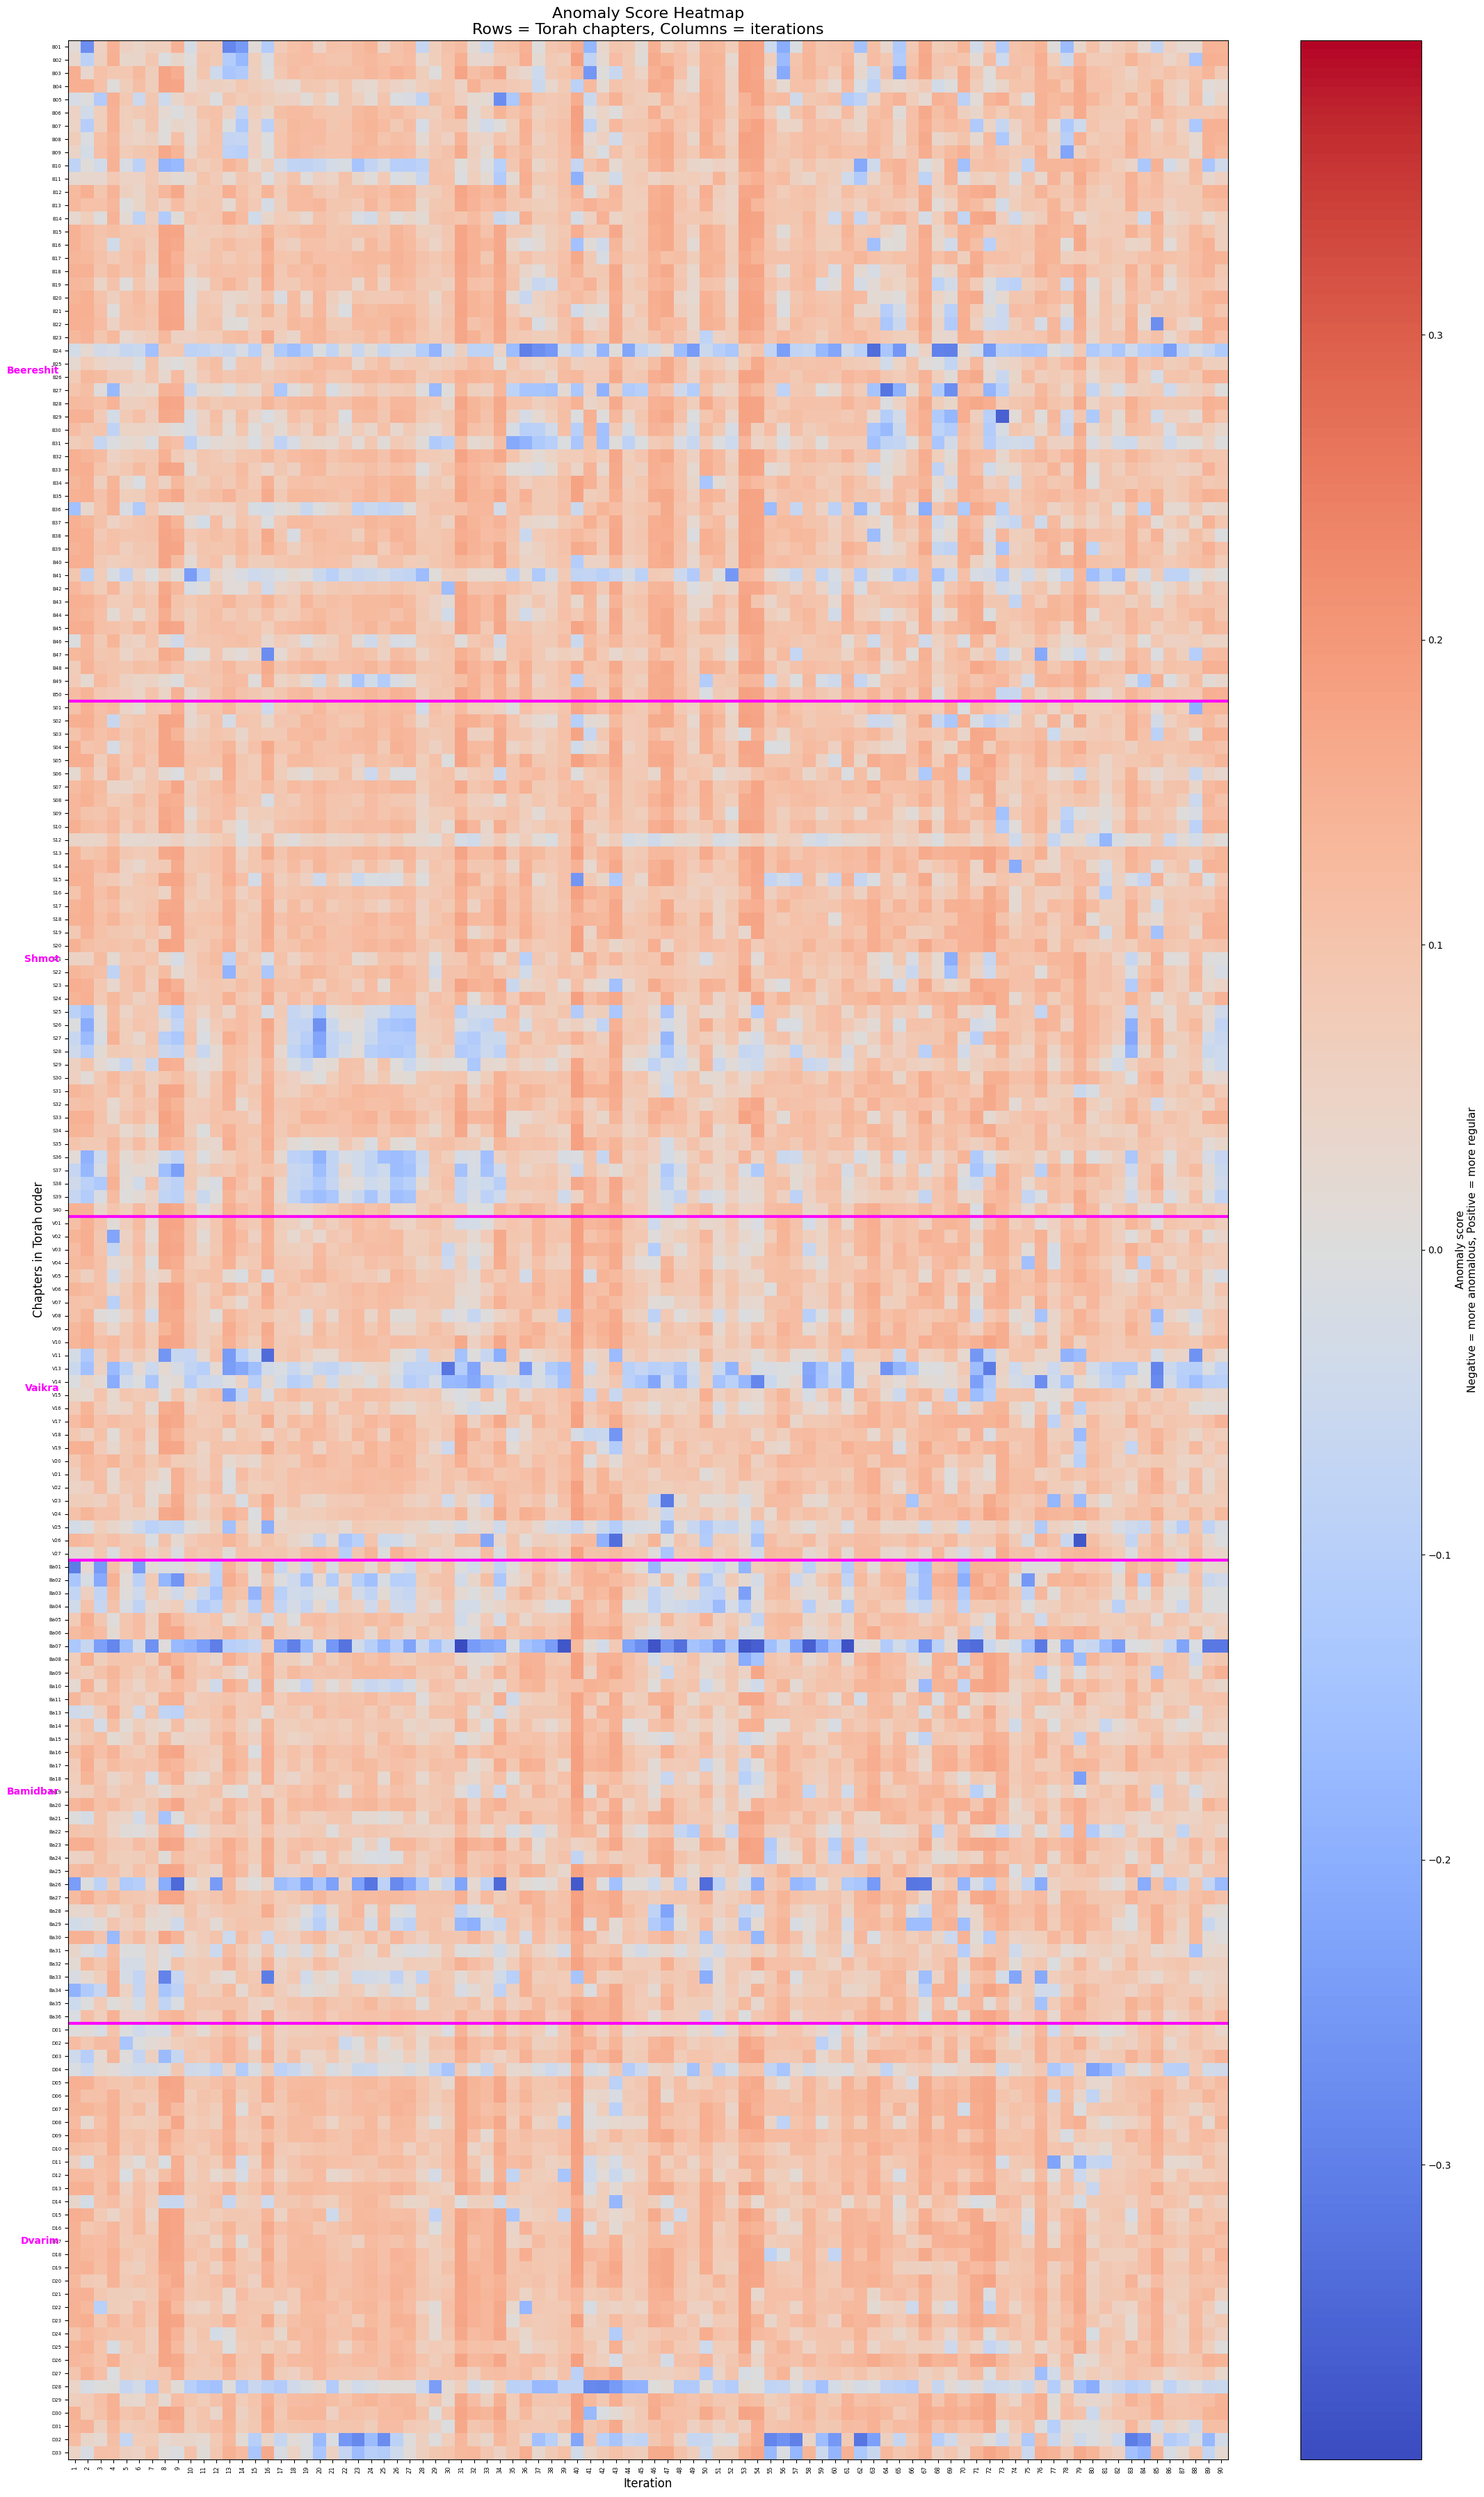

Helper table in Torah order:


,chapter,book,chapter_number,mean_anomaly_score,median_anomaly_score,min_anomaly_score,max_anomaly_score,negative_ratio
0,Beereshit_CH1,Beereshit,1,0.048260,0.079389,-0.285362,0.177399,0.188889
1,Beereshit_CH2,Beereshit,2,0.071884,0.090972,-0.173199,0.184783,0.122222
2,Beereshit_CH3,Beereshit,3,0.077517,0.099168,-0.253023,0.180515,0.111111
3,Beereshit_CH4,Beereshit,4,0.075201,0.074776,-0.086830,0.180428,0.055556
4,Beereshit_CH5,Beereshit,5,0.062005,0.076446,-0.275129,0.176228,0.200000
...,...,...,...,...,...,...,...,...
178,Dvarim_CH29,Dvarim,29,0.104469,0.110339,0.010180,0.184521,0.000000
179,Dvarim_CH30,Dvarim,30,0.106085,0.109745,-0.172797,0.184696,0.044444
180,Dvarim_CH31,Dvarim,31,0.090180,0.096572,-0.101346,0.175963,0.077778
181,Dvarim_CH32,Dvarim,32,-0.031047,0.001751,-0.317018,0.151267,0.500000


Color interpretation:
- Color on the negative side of the scale = negative anomaly score = a more anomalous chapter in that iteration.
- Color on the positive side of the scale = positive anomaly score = a more regular chapter in that iteration.
- 0 is centered on the colorbar, making it easier to see the transition between negative and positive values.


In [11]:
# ============================================================
# Cell:
# Heatmap of anomaly score
#
# Rows = chapters
# Columns = iterations
# Values = anomaly score
#
# X = iterations
# Y = chapters in Torah order
#
# Color:
# Negative value -> more anomalous
# Positive value -> more regular
#
# Colorbar with 0 in the center
# ============================================================


# ============================================================
# Preliminary checks
# ============================================================

if "analysis_df" not in globals():
    raise RuntimeError("analysis_df was not found. Run Cell 1 first.")

if "scores_df" not in globals():
    raise RuntimeError("scores_df was not found. Run Cell 1 first.")

if "score_columns" not in globals():
    raise RuntimeError("score_columns was not found. Run Cell 1 first.")


# ============================================================
# imports
# ============================================================

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm


# ============================================================
# Settings
# ============================================================

TORAH_BOOK_ORDER = [
    "Beereshit",
    "Shmot",
    "Vaikra",
    "Bamidbar",
    "Dvarim"
]

BOOK_ORDER_MAP = {
    book_name: index
    for index, book_name in enumerate(TORAH_BOOK_ORDER)
}

ANOMALY_HEATMAP_FIGSIZE = (22, 36)
ANOMALY_Y_LABEL_FONT_SIZE = 5
ANOMALY_X_LABEL_FONT_SIZE = 6

SHOW_ALL_ITERATION_TICKS = True
MAX_X_TICKS_IF_SAMPLING = 25

SHOW_CHAPTER_NAMES = True

BOOK_SEPARATOR_COLOR = "magenta"
BOOK_SEPARATOR_LINEWIDTH = 3


# ============================================================
# Helper functions
# ============================================================

def extract_chapter_number(chapter_name):
    """
    Extracts a chapter number from a name such as:
    Beereshit_CH01
    Shmot_CH12
    Bamidbar_CH7

    If no number is found, returns a large number so the chapter appears at the end of the book.
    """

    chapter_name = str(chapter_name)

    match = re.search(r"_CH0*(\d+)", chapter_name)
    if match:
        return int(match.group(1))

    match = re.search(r"(\d+)", chapter_name)
    if match:
        return int(match.group(1))

    return 10**9


def short_chapter_label(chapter_name):
    """
    Creates a short chapter label for the Y axis.

    Examples:
    Beereshit_CH01 -> B01
    Shmot_CH12     -> S12
    Vaikra_CH07    -> V07
    Bamidbar_CH04  -> Ba04
    Dvarim_CH03    -> D03
    """

    chapter_name = str(chapter_name)

    if "_CH" in chapter_name:
        book_name, chapter_part = chapter_name.split("_CH", 1)

        chapter_digits = re.sub(r"\D", "", chapter_part)
        chapter_num = int(chapter_digits) if chapter_digits else 0

        short_book_map = {
            "Beereshit": "B",
            "Shmot": "S",
            "Vaikra": "V",
            "Bamidbar": "Ba",
            "Dvarim": "D"
        }

        short_book = short_book_map.get(book_name, book_name[:2])

        return f"{short_book}{chapter_num:02d}"

    return chapter_name[:10]


# ============================================================
# Sort chapters by Torah order
# ============================================================

torah_order_df = analysis_df.copy()

# Save the original index so it can be used with scores_df
torah_order_df["original_index"] = torah_order_df.index

torah_order_df["book_order"] = torah_order_df["book"].map(BOOK_ORDER_MAP)
torah_order_df["chapter_number"] = torah_order_df["chapter"].apply(extract_chapter_number)

# Unrecognized books are moved to the end
torah_order_df["book_order"] = torah_order_df["book_order"].fillna(10**9)

torah_order_df = (
    torah_order_df
    .sort_values(["book_order", "chapter_number", "chapter"])
    .reset_index(drop=True)
)

torah_order_indices = torah_order_df["original_index"].to_numpy()


# ============================================================
# Build the anomaly score matrix in Torah order
# ============================================================

anomaly_matrix_sorted = scores_df.iloc[torah_order_indices].to_numpy()

chapter_labels_sorted = torah_order_df["chapter"].to_numpy()
short_chapter_labels_sorted = [
    short_chapter_label(ch)
    for ch in chapter_labels_sorted
]

iteration_labels = [str(col) for col in score_columns]


# ============================================================
# Compute boundaries between books
# ============================================================

book_sizes = (
    torah_order_df
    .groupby("book", sort=False)
    .size()
)

book_boundaries = []
book_centers = []
book_names_for_plot = []

start_index = 0

for book_name, size in book_sizes.items():

    end_index = start_index + size
    center = start_index + (size - 1) / 2

    book_centers.append(center)
    book_names_for_plot.append(book_name)

    book_boundaries.append(end_index - 0.5)

    start_index = end_index


# ============================================================
# Normalize colors around 0
#
# Idea:
# 0 will be exactly in the middle of the scale
# negative values on one side
# positive values on the other side
# ============================================================

max_abs_score = np.nanmax(np.abs(anomaly_matrix_sorted))

if max_abs_score == 0:
    max_abs_score = 1.0

color_norm = TwoSlopeNorm(
    vmin=-max_abs_score,
    vcenter=0.0,
    vmax=max_abs_score
)


# ============================================================
# Draw the heatmap
# ============================================================

plt.figure(figsize=ANOMALY_HEATMAP_FIGSIZE)

im = plt.imshow(
    anomaly_matrix_sorted,
    aspect="auto",
    interpolation="nearest",
    norm=color_norm,
    cmap="coolwarm"   # negative on one side, positive on the other
)

plt.title(
    "Anomaly Score Heatmap\nRows = Torah chapters, Columns = iterations",
    fontsize=16
)

plt.xlabel("Iteration", fontsize=12)
plt.ylabel("Chapters in Torah order", fontsize=12)


# ============================================================
# X axis = iterations
# ============================================================

n_iterations_local = anomaly_matrix_sorted.shape[1]

if SHOW_ALL_ITERATION_TICKS or n_iterations_local <= MAX_X_TICKS_IF_SAMPLING:
    x_ticks = np.arange(n_iterations_local)
    x_tick_labels = iteration_labels
else:
    x_ticks = np.linspace(0, n_iterations_local - 1, MAX_X_TICKS_IF_SAMPLING, dtype=int)
    x_tick_labels = [iteration_labels[i] for i in x_ticks]

plt.xticks(
    x_ticks,
    x_tick_labels,
    rotation=90,
    fontsize=ANOMALY_X_LABEL_FONT_SIZE
)


# ============================================================
# Y axis = chapters in Torah order
# ============================================================

if SHOW_CHAPTER_NAMES:
    plt.yticks(
        np.arange(len(short_chapter_labels_sorted)),
        short_chapter_labels_sorted,
        fontsize=ANOMALY_Y_LABEL_FONT_SIZE
    )


# ============================================================
# colorbar
# ============================================================

cbar = plt.colorbar(im)
cbar.set_label(
    "Anomaly score\nNegative = more anomalous, Positive = more regular",
    fontsize=11
)


# ============================================================
# Separator lines between books
# ============================================================

for boundary in book_boundaries[:-1]:
    plt.axhline(
        y=boundary,
        color=BOOK_SEPARATOR_COLOR,
        linewidth=BOOK_SEPARATOR_LINEWIDTH
    )


# ============================================================
# Book names on the left side
# ============================================================

for center, book_name in zip(book_centers, book_names_for_plot):
    plt.text(
        x=-1.2,
        y=center,
        s=book_name,
        ha="right",
        va="center",
        fontsize=10,
        fontweight="bold",
        color=BOOK_SEPARATOR_COLOR
    )


plt.tight_layout()
plt.show()


# ============================================================
# Helper table:
# Mean anomaly score for each chapter
# ============================================================

chapter_score_summary_df = torah_order_df[["chapter", "book", "chapter_number"]].copy()

chapter_score_summary_df["mean_anomaly_score"] = anomaly_matrix_sorted.mean(axis=1)
chapter_score_summary_df["median_anomaly_score"] = np.median(anomaly_matrix_sorted, axis=1)
chapter_score_summary_df["min_anomaly_score"] = anomaly_matrix_sorted.min(axis=1)
chapter_score_summary_df["max_anomaly_score"] = anomaly_matrix_sorted.max(axis=1)
chapter_score_summary_df["negative_ratio"] = (anomaly_matrix_sorted < 0).mean(axis=1)

print("Helper table in Torah order:")
display(
    chapter_score_summary_df.reset_index(drop=True)
)


# ============================================================
# Brief interpretation
# ============================================================

print("Color interpretation:")
print("- Color on the negative side of the scale = negative anomaly score = a more anomalous chapter in that iteration.")
print("- Color on the positive side of the scale = positive anomaly score = a more regular chapter in that iteration.")
print("- 0 is centered on the colorbar, making it easier to see the transition between negative and positive values.")